# EDA PM2.5 cho 3 tháng đầu năm 2026

Notebook này thực hiện 3 việc chính:
1. Cắt dữ liệu chỉ lấy từ tháng 01/2026 đến hết tháng 03/2026.
2. Chia train/test, trong đó test là 1 tuần cuối cùng của giai đoạn này.
3. Làm EDA chuỗi thời gian PM2.5 theo cách đơn giản, chân phương, dễ hiểu.

Mục tiêu cuối cùng là trả lời câu hỏi: **Chuỗi PM2.5 này vận động như thế nào theo thời gian, và mô hình cần học điều gì?**

In [2]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import MSTL

from sklearn.feature_selection import mutual_info_regression

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

## 1) Đọc dữ liệu và cắt đúng 3 tháng đầu năm 2026

Ta lấy dữ liệu từ file `TEST-aug-2025-mar-2026.csv`, sau đó chỉ giữ phần từ ngày 01/01/2026 đến 31/03/2026. Kết quả được lưu lại để dùng cho các bước sau.

In [3]:
data_dir = Path('Data')
source_path = data_dir / 'AQI_test_2025_10_to_2026_03.csv'

df_raw = pd.read_csv(source_path)
df_raw['Local Time'] = pd.to_datetime(df_raw['Local Time'])
df_raw['UTC Time'] = pd.to_datetime(df_raw['UTC Time'])
df_raw = df_raw.sort_values('Local Time').reset_index(drop=True)

start_time = pd.Timestamp('2026-01-01 00:00:00')
end_time = pd.Timestamp('2026-03-31 23:59:59')

df_q1_2026 = df_raw[(df_raw['Local Time'] >= start_time) & (df_raw['Local Time'] <= end_time)].copy()
df_q1_2026 = df_q1_2026.sort_values('Local Time').reset_index(drop=True)

q1_path = data_dir / 'PM25_2026_Q1_raw.csv'
df_q1_2026.to_csv(q1_path, index=False)

print('Dữ liệu gốc:', df_raw.shape)
print('Dữ liệu sau khi cắt Q1/2026:', df_q1_2026.shape)
print('File đã lưu:', q1_path)
df_q1_2026.head()

Dữ liệu gốc: (4368, 16)
Dữ liệu sau khi cắt Q1/2026: (2160, 16)
File đã lưu: Data\PM25_2026_Q1_raw.csv


,Local Time,UTC Time,Country Code,AQI,CO,NO2,O3,PM10,PM25,SO2,Clouds,Precipitation,Pressure,Relative Humidity,Temperature,Wind Speed
0,2026-01-01 00:00:00,2025-12-31 17:00:00+00:00,VN,123,639.0,33.4,50.0,39.5,38.4,32.0,99,0.1,1011.6,95,19.2,8.5
1,2026-01-01 01:00:00,2025-12-31 18:00:00+00:00,VN,122,622.0,31.7,51.0,40.4,39.3,30.4,47,0.0,1011.5,96,19.1,9.2
2,2026-01-01 02:00:00,2025-12-31 19:00:00+00:00,VN,121,553.0,29.4,52.0,39.5,38.4,28.8,71,0.1,1011.2,95,19.0,8.8
3,2026-01-01 03:00:00,2025-12-31 20:00:00+00:00,VN,120,463.0,27.0,55.0,37.7,36.8,27.4,100,0.1,1011.1,96,18.9,9.6
4,2026-01-01 04:00:00,2025-12-31 21:00:00+00:00,VN,118,419.0,26.3,56.0,36.4,35.5,27.3,95,0.1,1011.2,98,18.5,10.0


## 2) Chia train/test

Theo yêu cầu, tập test chỉ là 1 tuần cuối cùng của 3 tháng đầu năm 2026. Phần còn lại là train. Sau đó lưu lại thành 2 file mới.

In [4]:
# Lấy 7 ngày cuối cùng làm test
split_start = df_q1_2026['Local Time'].max().normalize() - pd.Timedelta(days=6)

df_train = df_q1_2026[df_q1_2026['Local Time'] < split_start].copy()
df_test = df_q1_2026[df_q1_2026['Local Time'] >= split_start].copy()

df_train = df_train.sort_values('Local Time').reset_index(drop=True)
df_test = df_test.sort_values('Local Time').reset_index(drop=True)

train_path = data_dir / 'PM25_2026_Q1_train.csv'
test_path = data_dir / 'PM25_2026_Q1_test_1week.csv'

df_train.to_csv(train_path, index=False)
df_test.to_csv(test_path, index=False)

print('Mốc tách test bắt đầu từ:', split_start)
print('Train shape:', df_train.shape)
print('Test shape :', df_test.shape)
print('File train đã lưu:', train_path)
print('File test đã lưu :', test_path)

Mốc tách test bắt đầu từ: 2026-03-25 00:00:00
Train shape: (1992, 16)
Test shape : (168, 16)
File train đã lưu: Data\PM25_2026_Q1_train.csv
File test đã lưu : Data\PM25_2026_Q1_test_1week.csv


## 3) Kiểm tra cấu trúc dữ liệu

Phần này kiểm tra số dòng, số cột, missing timestamps, timestamp bị lặp và dòng trùng hoàn toàn cho từng file.

In [5]:
def check_data_integrity(df, name):
    print('=' * 70)
    print(name)
    print('=' * 70)
    print('Số dòng:', df.shape[0])
    print('Số cột:', df.shape[1])

    if 'Local Time' not in df.columns:
        print('Không tìm thấy cột Local Time')
        return

    time_series = pd.to_datetime(df['Local Time']).dropna().sort_values()
    unique_time_series = time_series.drop_duplicates()
    expected_range = pd.date_range(unique_time_series.min(), unique_time_series.max(), freq='H')
    missing_timestamps = expected_range.difference(unique_time_series)
    duplicate_timestamps = df['Local Time'].duplicated().sum()
    duplicate_rows = df.duplicated().sum()

    print('Thời gian bắt đầu:', unique_time_series.min())
    print('Thời gian kết thúc:', unique_time_series.max())
    print('Số mốc thời gian kỳ vọng:', len(expected_range))
    print('Số mốc thời gian thực tế:', len(unique_time_series))
    print('Số timestamp bị thiếu:', len(missing_timestamps))
    print('Số timestamp bị lặp:', duplicate_timestamps)
    print('Số dòng trùng hoàn toàn:', duplicate_rows)

    if len(missing_timestamps) > 0:
        print('Một vài timestamp bị thiếu:')
        print(missing_timestamps[:20])
    else:
        print('Không phát hiện timestamp bị thiếu.')

    print()

check_data_integrity(df_q1_2026, 'Q1/2026 - dữ liệu sau khi cắt')

Q1/2026 - dữ liệu sau khi cắt
Số dòng: 2160
Số cột: 16
Thời gian bắt đầu: 2026-01-01 00:00:00
Thời gian kết thúc: 2026-03-31 23:00:00
Số mốc thời gian kỳ vọng: 2160
Số mốc thời gian thực tế: 2160
Số timestamp bị thiếu: 0
Số timestamp bị lặp: 0
Số dòng trùng hoàn toàn: 0
Không phát hiện timestamp bị thiếu.



In [6]:
check_data_integrity(df_train, 'Train')
check_data_integrity(df_test, 'Test')

Train
Số dòng: 1992
Số cột: 16
Thời gian bắt đầu: 2026-01-01 00:00:00
Thời gian kết thúc: 2026-03-24 23:00:00
Số mốc thời gian kỳ vọng: 1992
Số mốc thời gian thực tế: 1992
Số timestamp bị thiếu: 0
Số timestamp bị lặp: 0
Số dòng trùng hoàn toàn: 0
Không phát hiện timestamp bị thiếu.

Test
Số dòng: 168
Số cột: 16
Thời gian bắt đầu: 2026-03-25 00:00:00
Thời gian kết thúc: 2026-03-31 23:00:00
Số mốc thời gian kỳ vọng: 168
Số mốc thời gian thực tế: 168
Số timestamp bị thiếu: 0
Số timestamp bị lặp: 0
Số dòng trùng hoàn toàn: 0
Không phát hiện timestamp bị thiếu.



In [7]:
df_q1_2026.describe()

,Local Time,AQI,CO,NO2,O3,PM10,PM25,SO2,Clouds,Precipitation,Pressure,Relative Humidity,Temperature,Wind Speed
count,2160,2160.000000,2160.000000,2160.000000,2160.000000,2160.000000,2160.000000,2160.000000,2160.000000,2160.000000,2160.000000,2160.00000,2160.000000,2160.000000
mean,2026-02-14 23:29:59.999999744,129.638889,773.819907,34.898148,54.097222,55.238704,53.883796,40.031898,70.051852,0.055093,1014.936898,81.07963,20.459861,9.420231
min,2026-01-01 00:00:00,52.000000,259.000000,2.400000,0.000000,5.200000,4.900000,14.100000,0.000000,0.000000,1001.200000,38.00000,9.600000,0.300000
25%,2026-01-23 11:45:00,105.000000,476.000000,21.475000,27.000000,35.300000,33.800000,30.500000,33.000000,0.000000,1010.800000,72.00000,17.675000,6.000000
50%,2026-02-14 23:30:00,131.000000,649.000000,33.000000,43.000000,48.100000,46.600000,36.400000,99.000000,0.000000,1015.200000,83.00000,20.600000,9.550000
75%,2026-03-09 11:15:00,156.000000,883.000000,44.600000,72.000000,67.800000,66.400000,46.825000,100.000000,0.000000,1019.200000,92.00000,23.500000,12.400000
max,2026-03-31 23:00:00,205.000000,4041.000000,99.200000,257.000000,174.600000,173.700000,113.700000,100.000000,14.500000,1029.000000,100.00000,36.800000,25.400000
std,NaN,31.599848,469.313814,17.013601,39.574413,29.611624,29.598338,13.854358,38.359602,0.365793,5.690251,12.89158,4.361462,4.360372


## 4) Phân tích xu hướng dài hạn

Vì chỉ có 3 tháng đầu năm 2026 nên ta không xem xu hướng theo năm, mà xem xu hướng theo toàn bộ giai đoạn 3 tháng, theo tháng và theo rolling mean.

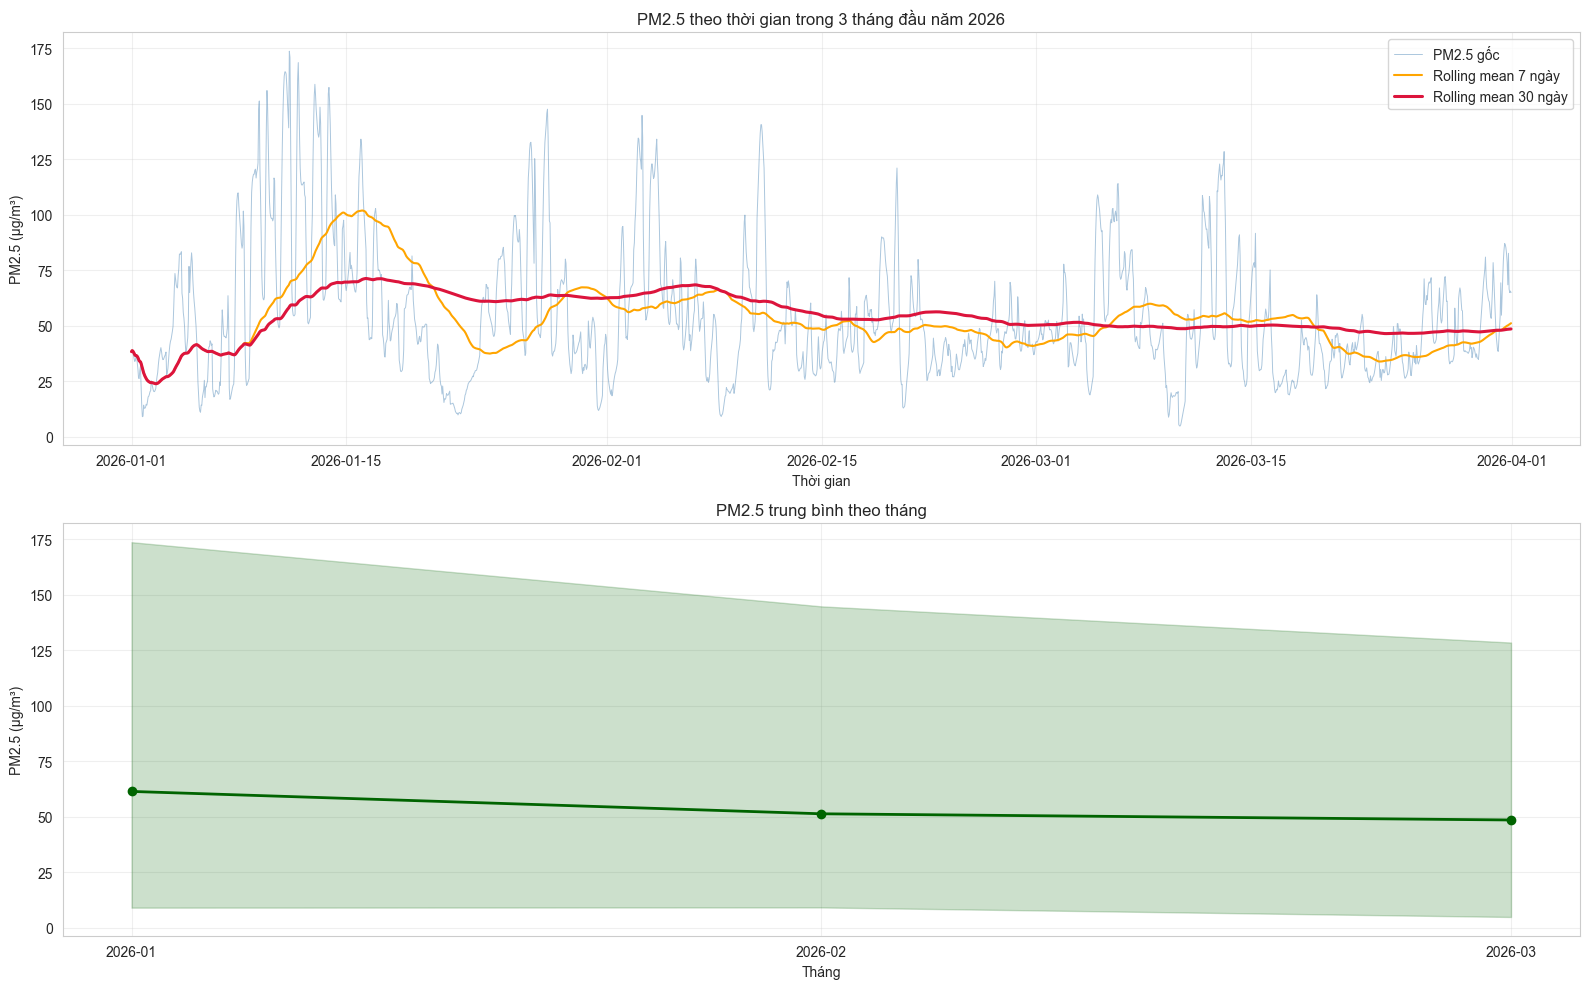

,Local Time,mean,median,std,min,max,month_label,month_idx
0,2026-01,61.447581,52.35,37.011914,9.1,173.7,2026-01,0
1,2026-02,51.376488,46.65,25.220419,9.2,144.8,2026-02,1
2,2026-03,48.584677,43.70,22.588565,4.9,128.5,2026-03,2


In [8]:
pm25_hourly = df_q1_2026.set_index('Local Time')['PM25'].sort_index()
pm25_hourly_full = pm25_hourly.asfreq('H').interpolate(limit_direction='both')

rolling_7d = pm25_hourly_full.rolling('7D').mean()
rolling_30d = pm25_hourly_full.rolling('30D').mean()

pm25_by_month = df_q1_2026.groupby(df_q1_2026['Local Time'].dt.to_period('M'))['PM25'].agg(['mean', 'median', 'std', 'min', 'max']).reset_index()
pm25_by_month['month_label'] = pm25_by_month['Local Time'].astype(str)
pm25_by_month['month_idx'] = np.arange(len(pm25_by_month))

fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=False)

axes[0].plot(pm25_hourly_full.index, pm25_hourly_full.values, color='steelblue', linewidth=0.7, alpha=0.45, label='PM2.5 gốc')
axes[0].plot(rolling_7d.index, rolling_7d.values, color='orange', linewidth=1.5, label='Rolling mean 7 ngày')
axes[0].plot(rolling_30d.index, rolling_30d.values, color='crimson', linewidth=2.2, label='Rolling mean 30 ngày')
axes[0].set_title('PM2.5 theo thời gian trong 3 tháng đầu năm 2026')
axes[0].set_xlabel('Thời gian')
axes[0].set_ylabel('PM2.5 (µg/m³)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(pm25_by_month['month_idx'], pm25_by_month['mean'], marker='o', color='darkgreen', linewidth=2, label='Trung bình')
axes[1].fill_between(pm25_by_month['month_idx'], pm25_by_month['min'], pm25_by_month['max'], alpha=0.2, color='darkgreen')
axes[1].set_title('PM2.5 trung bình theo tháng')
axes[1].set_xlabel('Tháng')
axes[1].set_ylabel('PM2.5 (µg/m³)')
axes[1].set_xticks(pm25_by_month['month_idx'])
axes[1].set_xticklabels(pm25_by_month['month_label'])
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

display(pm25_by_month)

In [9]:
# Tìm giờ cao nhất và thấp nhất PM2.5 trong từng tháng
df_q1_2026['month'] = df_q1_2026['Local Time'].dt.to_period('M')
df_q1_2026['date'] = df_q1_2026['Local Time'].dt.date
df_q1_2026['hour'] = df_q1_2026['Local Time'].dt.hour

# Tìm hàng có PM2.5 cao nhất trong mỗi tháng
highest_idx = df_q1_2026.groupby('month')['PM25'].idxmax()
highest_records = df_q1_2026.loc[highest_idx]

# Tìm hàng có PM2.5 thấp nhất trong mỗi tháng
lowest_idx = df_q1_2026.groupby('month')['PM25'].idxmin()
lowest_records = df_q1_2026.loc[lowest_idx]

print('GIỜ CÓ PM2.5 CAO NHẤT TRONG MỖI THÁNG')
# result_highest = highest_records[['month', 'Local Time', 'date', 'hour', 'PM25']].copy()
# result_highest['hour_str'] = result_highest['hour'].astype(str).str.zfill(2) + ':00'
# result_highest['Tháng'] = result_highest['month'].astype(str)
# result_highest['Ngày'] = result_highest['date'].astype(str)
# result_highest['Giờ'] = result_highest['hour_str']
# result_highest['PM2.5 (µg/m³)'] = result_highest['PM25'].round(2)
# display(result_highest[['Tháng', 'Ngày', 'Giờ', 'PM2.5 (µg/m³)']])
display(highest_records)

print('\n' + '=' * 90 + '\n')
print('GIỜ CÓ PM2.5 THẤP NHẤT TRONG MỖI THÁNG')
# result_lowest = lowest_records[['month', 'Local Time', 'date', 'hour', 'PM25']].copy()
# result_lowest['hour_str'] = result_lowest['hour'].astype(str).str.zfill(2) + ':00'
# result_lowest['Tháng'] = result_lowest['month'].astype(str)
# result_lowest['Ngày'] = result_lowest['date'].astype(str)
# result_lowest['Giờ'] = result_lowest['hour_str']
# result_lowest['PM2.5 (µg/m³)'] = result_lowest['PM25'].round(2)
# display(result_lowest[['Tháng', 'Ngày', 'Giờ', 'PM2.5 (µg/m³)']])
display(lowest_records)

GIỜ CÓ PM2.5 CAO NHẤT TRONG MỖI THÁNG


,Local Time,UTC Time,Country Code,AQI,CO,NO2,O3,PM10,PM25,SO2,Clouds,Precipitation,Pressure,Relative Humidity,Temperature,Wind Speed,month,date,hour
247,2026-01-11 07:00:00,2026-01-11 00:00:00+00:00,VN,179,1569.0,61.9,11.0,174.6,173.7,66.8,66,0.0,1024.2,91,12.4,6.7,2026-01,2026-01-11,7
799,2026-02-03 07:00:00,2026-02-03 00:00:00+00:00,VN,168,1749.0,53.9,5.0,146.2,144.8,69.1,100,0.0,1023.6,95,13.6,3.7,2026-02,2026-02-03,7
1710,2026-03-13 06:00:00,2026-03-12 23:00:00+00:00,VN,168,2020.0,70.1,12.0,129.5,128.5,84.5,48,0.0,1019.1,96,16.8,3.7,2026-03,2026-03-13,6




GIỜ CÓ PM2.5 THẤP NHẤT TRONG MỖI THÁNG


,Local Time,UTC Time,Country Code,AQI,CO,NO2,O3,PM10,PM25,SO2,Clouds,Precipitation,Pressure,Relative Humidity,Temperature,Wind Speed,month,date,hour
17,2026-01-01 17:00:00,2026-01-01 10:00:00+00:00,VN,95,724.0,19.7,70.0,9.1,9.1,27.4,100,0.1,1015.5,84,20.0,15.0,2026-01,2026-01-01,17
923,2026-02-08 11:00:00,2026-02-08 04:00:00+00:00,VN,96,925.0,14.5,39.0,9.3,9.2,25.8,100,1.1,1024.4,90,14.4,13.5,2026-02,2026-02-08,11
1641,2026-03-10 09:00:00,2026-03-10 02:00:00+00:00,VN,62,674.0,10.2,82.0,5.2,4.9,15.3,2,0.0,1025.0,60,17.5,11.4,2026-03,2026-03-10,9


In [10]:
# xem dữ liệu từ ngày 14/2 đến ngày 22/2 - Tết âm lịch
df_tet = df_q1_2026[(df_q1_2026['Local Time'].dt.date >= pd.Timestamp('2026-02-14').date()) & (df_q1_2026['Local Time'].dt.date <= pd.Timestamp('2026-02-22').date())]

df_tet.head(3)

,Local Time,UTC Time,Country Code,AQI,CO,NO2,O3,PM10,PM25,SO2,Clouds,Precipitation,Pressure,Relative Humidity,Temperature,Wind Speed,month,date,hour
1056,2026-02-14 00:00:00,2026-02-13 17:00:00+00:00,VN,109,511.0,29.9,44.0,35.6,32.9,30.7,33,0.0,1014.9,95,20.2,9.8,2026-02,2026-02-14,0
1057,2026-02-14 01:00:00,2026-02-13 18:00:00+00:00,VN,107,505.0,29.7,40.0,40.5,37.7,29.0,55,0.0,1014.6,96,20.9,10.7,2026-02,2026-02-14,1
1058,2026-02-14 02:00:00,2026-02-13 19:00:00+00:00,VN,106,473.0,28.8,36.0,46.3,44.4,27.7,77,0.0,1014.0,97,20.6,9.5,2026-02,2026-02-14,2


In [11]:
# # tìm giờ cao nhất và thấp nhất trong df_tet
# highest_idx_tet = df_tet['PM25'].idxmax()
# lowest_idx_tet = df_tet['PM25'].idxmin()

# highest_record_tet = df_tet.loc[highest_idx_tet]
# lowest_record_tet = df_tet.loc[lowest_idx_tet]

# print('GIỜ CÓ PM2.5 CAO NHẤT TRONG KỲ TẾT')
# display(highest_record_tet)

# print('\n' + '=' * 90 + '\n')
# print('GIỜ CÓ PM2.5 THẤP NHẤT TRONG KỲ TẾT')
# display(lowest_record_tet)

In [12]:
# tìm 5 giờ cao nhất và 5 giờ thấp nhất trong df_tet
top_5_highest_records = df_tet.nlargest(5, 'PM25')
top_5_lowest_records = df_tet.nsmallest(5, 'PM25')

# In kết quả (chỉ hiển thị vài cột quan trọng cho dễ nhìn)
cols_to_show = ['Local Time', 'PM25', 'Temperature', 'Wind Speed'] # Thay đổi tùy ý bạn

print("--- 5 THỜI ĐIỂM Ô NHIỄM ĐỈNH ĐIỂM ---")
display(top_5_highest_records[cols_to_show])

print("\n--- 5 THỜI ĐIỂM KHÔNG KHÍ TRONG LÀNH NHẤT ---")
display(top_5_lowest_records[cols_to_show])

--- 5 THỜI ĐIỂM Ô NHIỄM ĐỈNH ĐIỂM ---


,Local Time,PM25,Temperature,Wind Speed
1198,2026-02-19 22:00:00,121.1,19.3,7.5
1197,2026-02-19 21:00:00,114.3,19.6,10.1
1199,2026-02-19 23:00:00,108.5,18.8,8.8
1196,2026-02-19 20:00:00,102.9,19.8,7.0
1200,2026-02-20 00:00:00,90.6,18.0,11.3



--- 5 THỜI ĐIỂM KHÔNG KHÍ TRONG LÀNH NHẤT ---


,Local Time,PM25,Temperature,Wind Speed
1208,2026-02-20 08:00:00,13.0,17.4,3.6
1209,2026-02-20 09:00:00,13.4,18.4,5.1
1207,2026-02-20 07:00:00,13.5,16.9,4.7
1210,2026-02-20 10:00:00,13.8,20.0,5.8
1211,2026-02-20 11:00:00,16.1,21.6,5.5


## 5) Phân phối dữ liệu

Dùng histogram, KDE và boxplot để nhìn nhanh PM2.5 phân bố như thế nào và có nhiều giá trị cực đoan hay không.

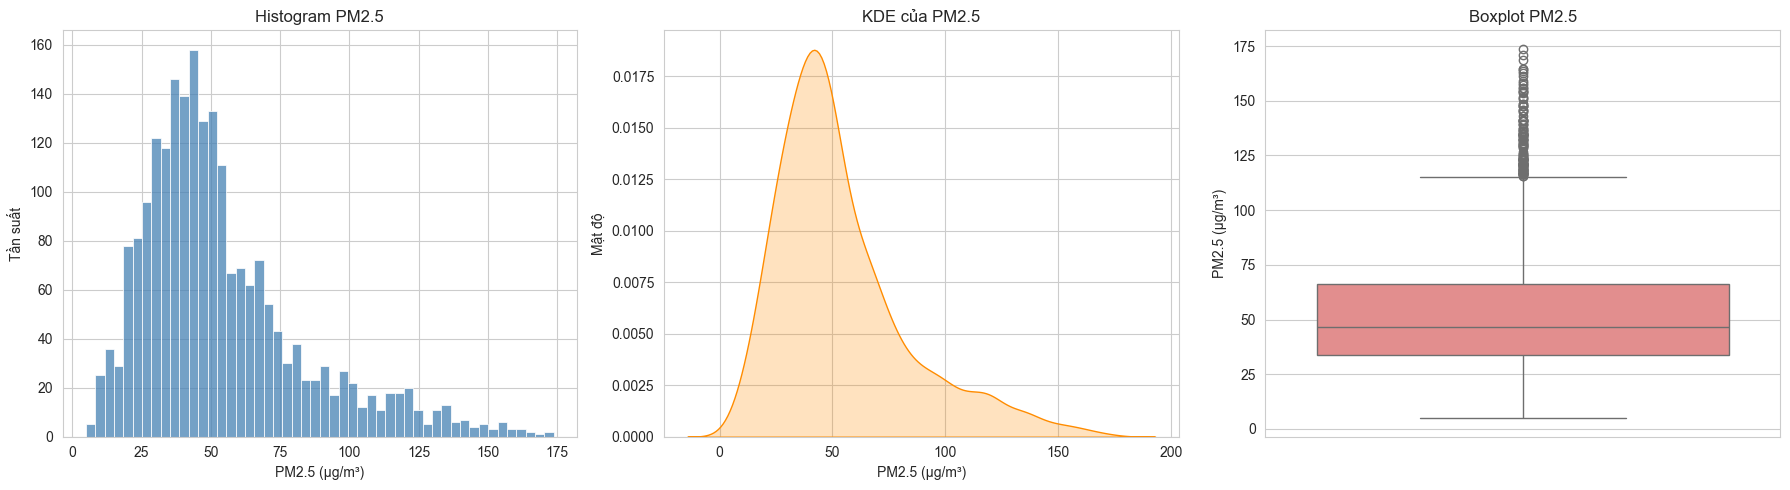

count    2160.000000
mean       53.883796
std        29.598338
min         4.900000
25%        33.800000
50%        46.600000
75%        66.400000
max       173.700000
Name: PM25, dtype: float64


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df_q1_2026['PM25'].dropna(), bins=50, kde=False, color='steelblue', ax=axes[0])
axes[0].set_title('Histogram PM2.5')
axes[0].set_xlabel('PM2.5 (µg/m³)')
axes[0].set_ylabel('Tần suất')

sns.kdeplot(df_q1_2026['PM25'].dropna(), fill=True, color='darkorange', ax=axes[1])
axes[1].set_title('KDE của PM2.5')
axes[1].set_xlabel('PM2.5 (µg/m³)')
axes[1].set_ylabel('Mật độ')

sns.boxplot(y=df_q1_2026['PM25'], color='lightcoral', ax=axes[2])
axes[2].set_title('Boxplot PM2.5')
axes[2].set_ylabel('PM2.5 (µg/m³)')

plt.tight_layout()
plt.show()

print(df_q1_2026['PM25'].describe())

## 6) Seasonality

Ta kiểm tra chu kỳ theo giờ trong ngày, theo ngày trong tuần, theo tháng và theo mùa. Với dữ liệu chỉ 3 tháng, phần mùa chủ yếu sẽ thấy rõ mùa đông và đầu xuân.

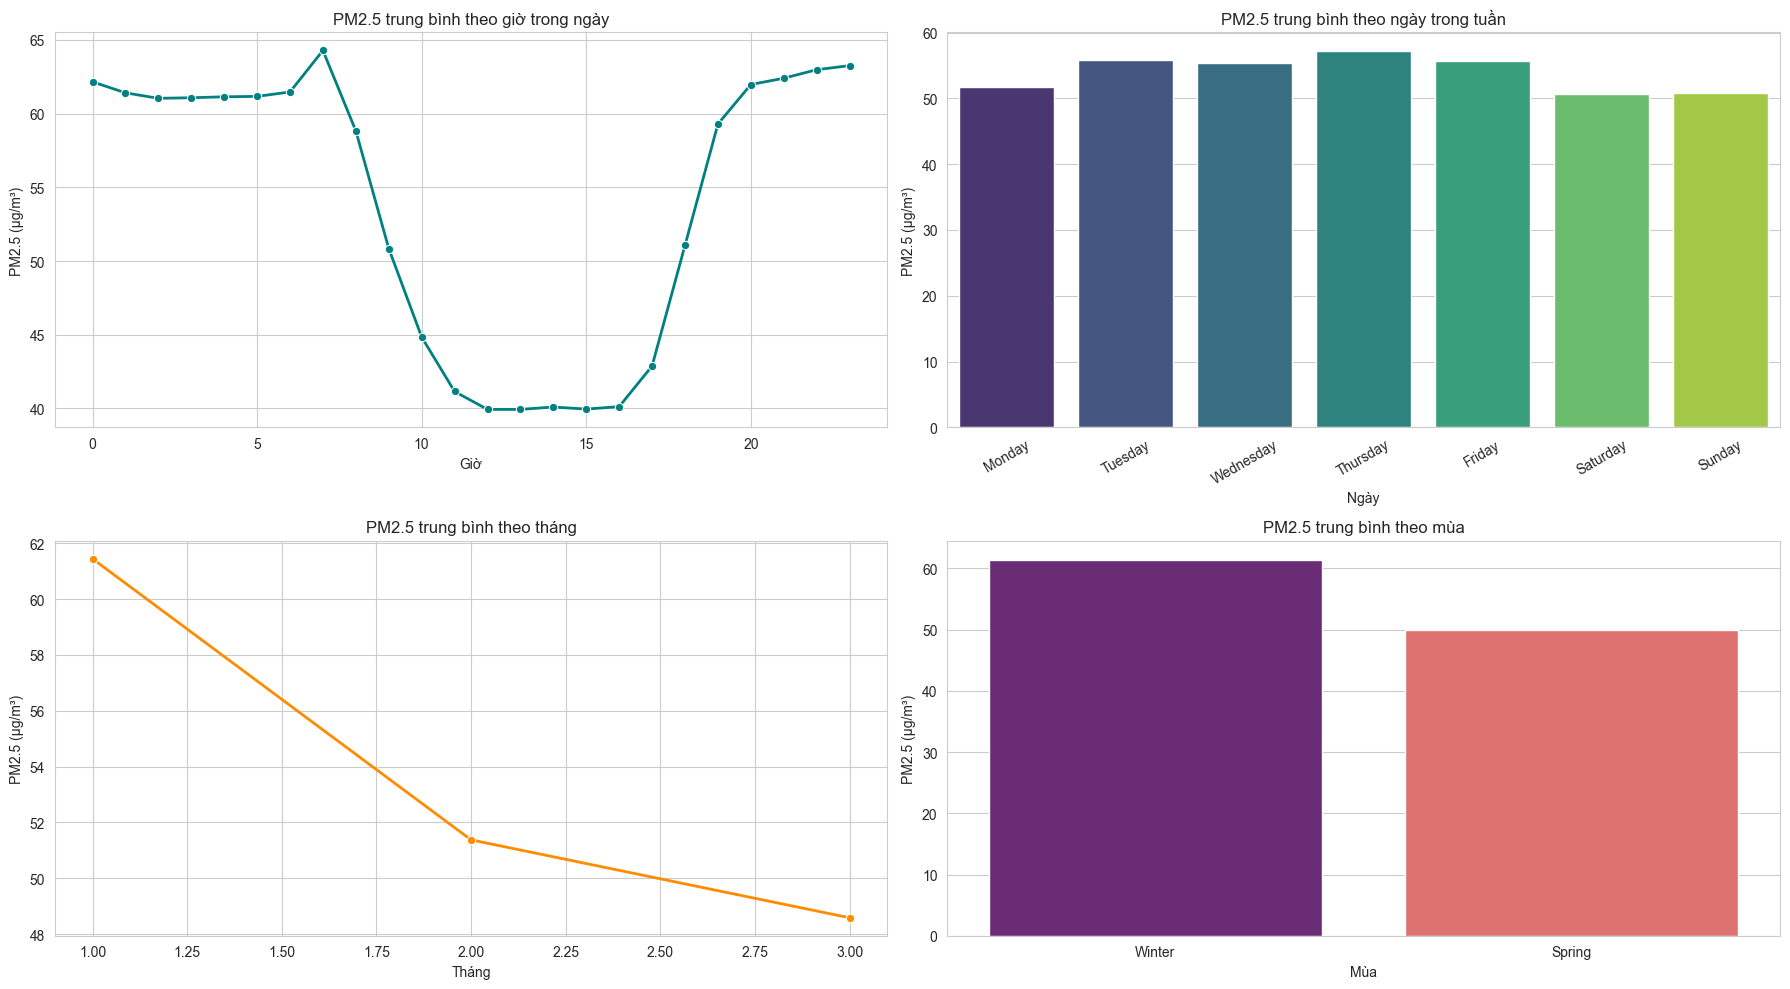

In [14]:
df_season = df_q1_2026.copy()
df_season['hour'] = df_season['Local Time'].dt.hour
df_season['day_of_week'] = df_season['Local Time'].dt.day_name()
df_season['month'] = df_season['Local Time'].dt.month

season_map = {1: 'Winter', 2: 'Spring', 3: 'Spring'}
df_season['season'] = df_season['month'].map(season_map)

hourly_mean = df_season.groupby('hour')['PM25'].mean().reset_index()
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_mean = df_season.groupby('day_of_week')['PM25'].mean().reindex(weekday_order).reset_index()
monthly_mean = df_season.groupby('month')['PM25'].mean().reset_index()
season_order = ['Winter', 'Spring']
season_mean = df_season.groupby('season')['PM25'].mean().reindex(season_order).reset_index()

fig, axes = plt.subplots(2, 2, figsize=(18, 10))

sns.lineplot(data=hourly_mean, x='hour', y='PM25', marker='o', ax=axes[0, 0], color='teal', linewidth=2)
axes[0, 0].set_title('PM2.5 trung bình theo giờ trong ngày')
axes[0, 0].set_xlabel('Giờ')
axes[0, 0].set_ylabel('PM2.5 (µg/m³)')

sns.barplot(data=weekday_mean, x='day_of_week', y='PM25', ax=axes[0, 1], palette='viridis')
axes[0, 1].set_title('PM2.5 trung bình theo ngày trong tuần')
axes[0, 1].set_xlabel('Ngày')
axes[0, 1].set_ylabel('PM2.5 (µg/m³)')
axes[0, 1].tick_params(axis='x', rotation=30)

sns.lineplot(data=monthly_mean, x='month', y='PM25', marker='o', ax=axes[1, 0], color='darkorange', linewidth=2)
axes[1, 0].set_title('PM2.5 trung bình theo tháng')
axes[1, 0].set_xlabel('Tháng')
axes[1, 0].set_ylabel('PM2.5 (µg/m³)')

sns.barplot(data=season_mean, x='season', y='PM25', ax=axes[1, 1], palette='magma')
axes[1, 1].set_title('PM2.5 trung bình theo mùa')
axes[1, 1].set_xlabel('Mùa')
axes[1, 1].set_ylabel('PM2.5 (µg/m³)')

plt.tight_layout()
plt.show()

## 7) ACF và PACF

ACF và PACF giúp phát hiện các độ trễ quan trọng như 24 giờ, 168 giờ.
Ta sẽ nhìn trên chuỗi gốc, chuỗi log, chuỗi sai phân và chuỗi diff(log).

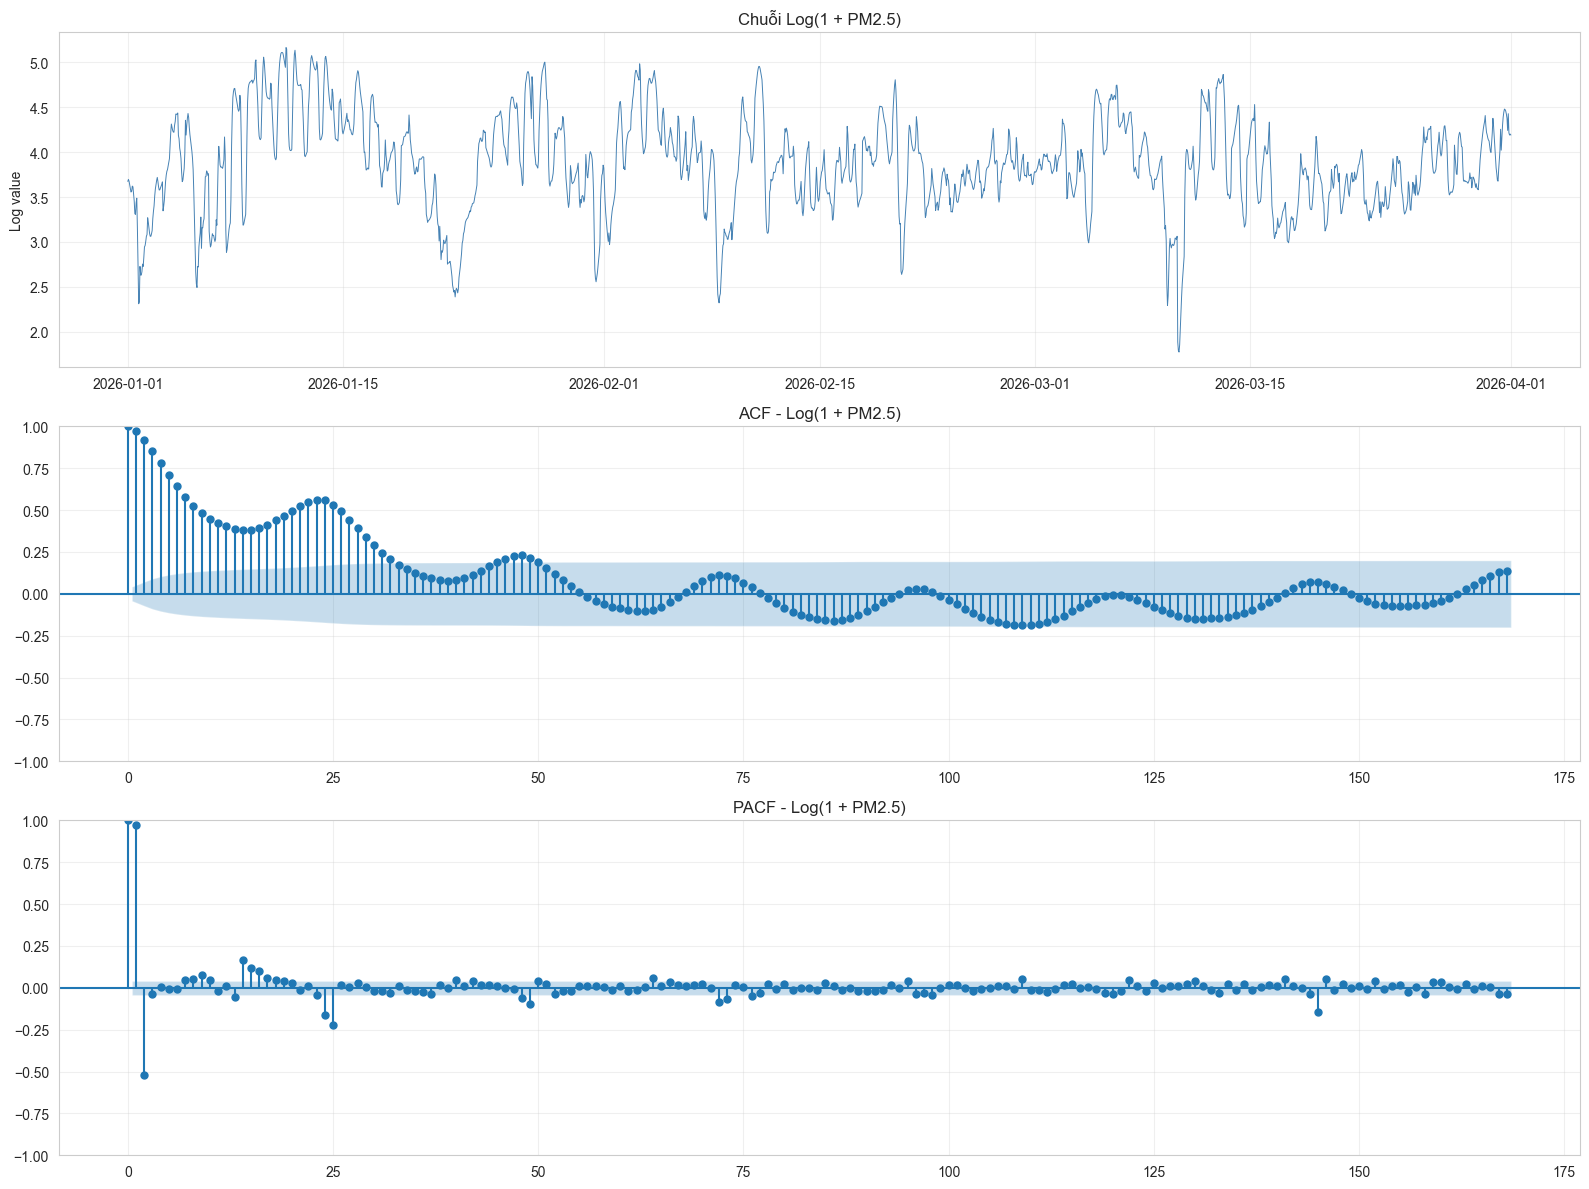

In [15]:
pm25_log = np.log1p(pm25_hourly_full)
pm25_diff = pm25_hourly_full.diff().dropna()
pm25_log_diff = pm25_log.diff().dropna()

fig, axes = plt.subplots(3, 1, figsize=(16, 12))

axes[0].plot(pm25_log.index, pm25_log.values, color='steelblue', linewidth=0.7)
axes[0].set_title('Chuỗi Log(1 + PM2.5)')
axes[0].set_ylabel('Log value')
axes[0].grid(True, alpha=0.3)
plot_acf(pm25_log.dropna(), lags=24 * 7, ax=axes[1])
axes[1].set_title('ACF - Log(1 + PM2.5)')
axes[1].grid(True, alpha=0.3)
plot_pacf(pm25_log.dropna(), lags=24 * 7, ax=axes[2], method='ywm')
axes[2].set_title('PACF - Log(1 + PM2.5)')
axes[2].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

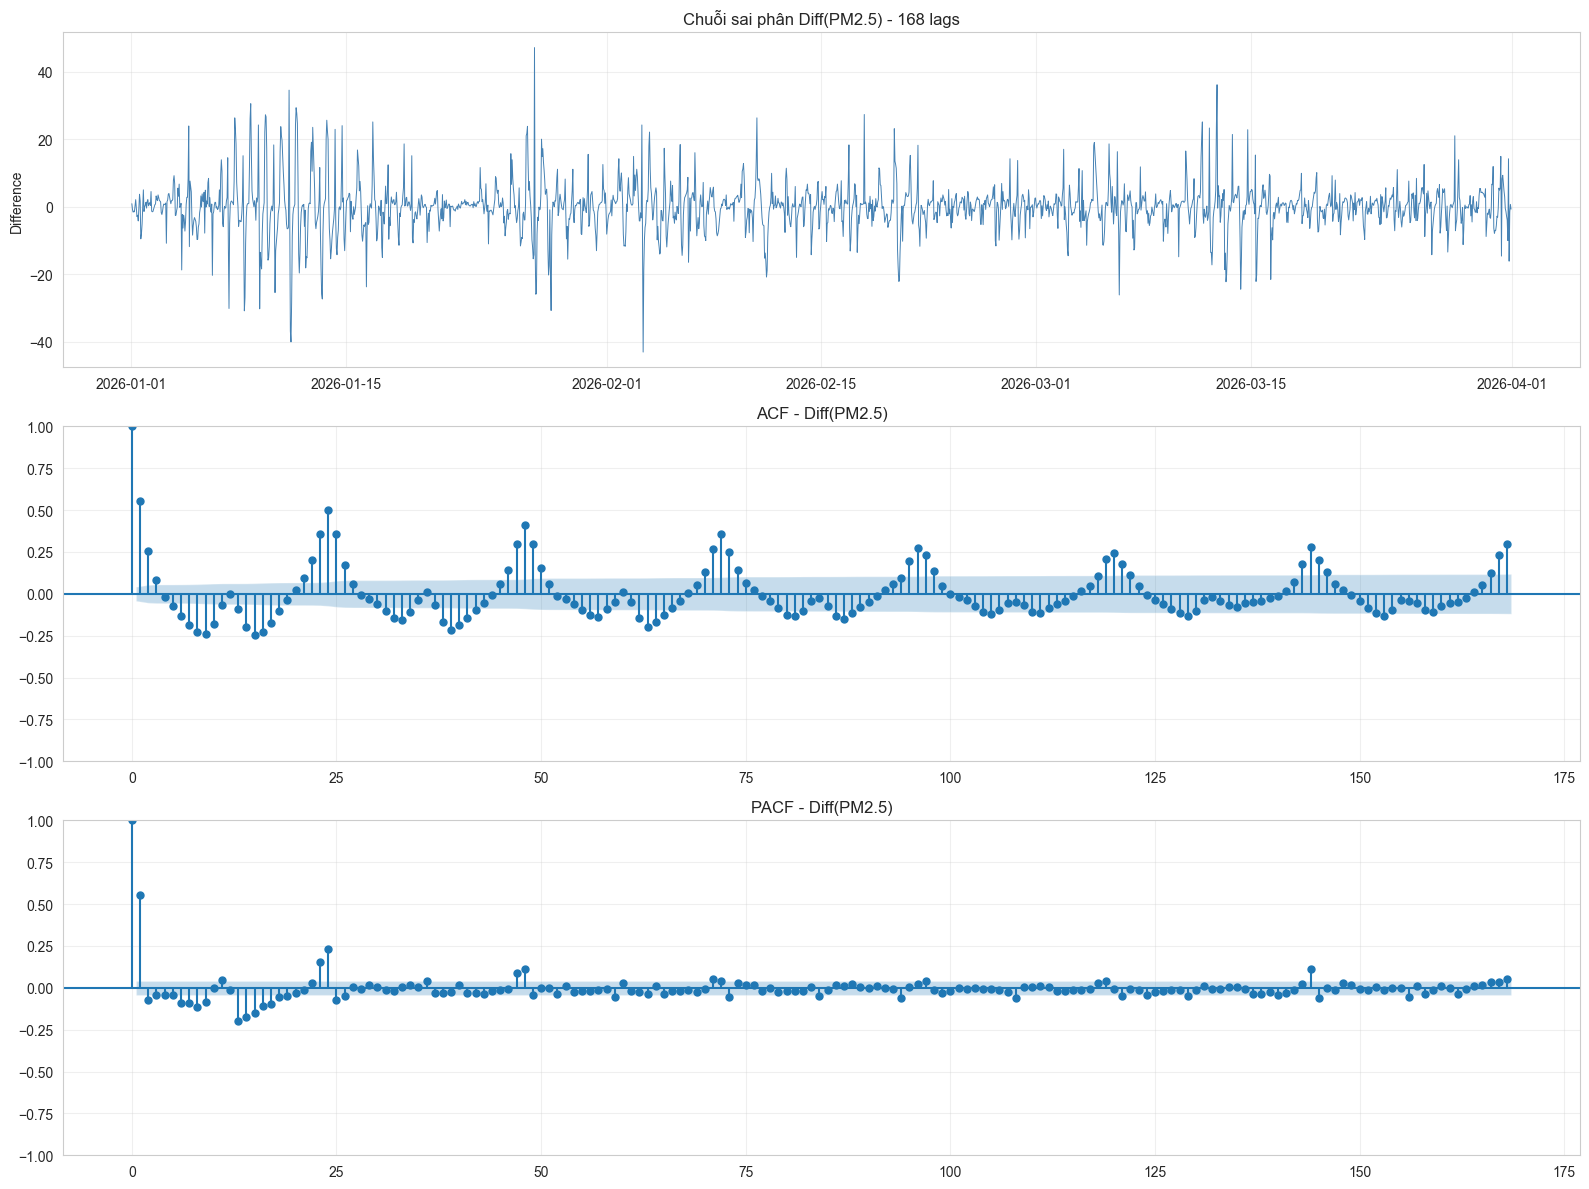

In [16]:
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

axes[0].plot(pm25_diff.index, pm25_diff.values, color='steelblue', linewidth=0.7)
axes[0].set_title('Chuỗi sai phân Diff(PM2.5) - 168 lags')
axes[0].set_ylabel('Difference')
axes[0].grid(True, alpha=0.3)
plot_acf(pm25_diff.dropna(), lags=24 * 7, ax=axes[1])
axes[1].set_title('ACF - Diff(PM2.5)')
axes[1].grid(True, alpha=0.3)
plot_pacf(pm25_diff.dropna(), lags=24 * 7, ax=axes[2], method='ywm')
axes[2].set_title('PACF - Diff(PM2.5)')
axes[2].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

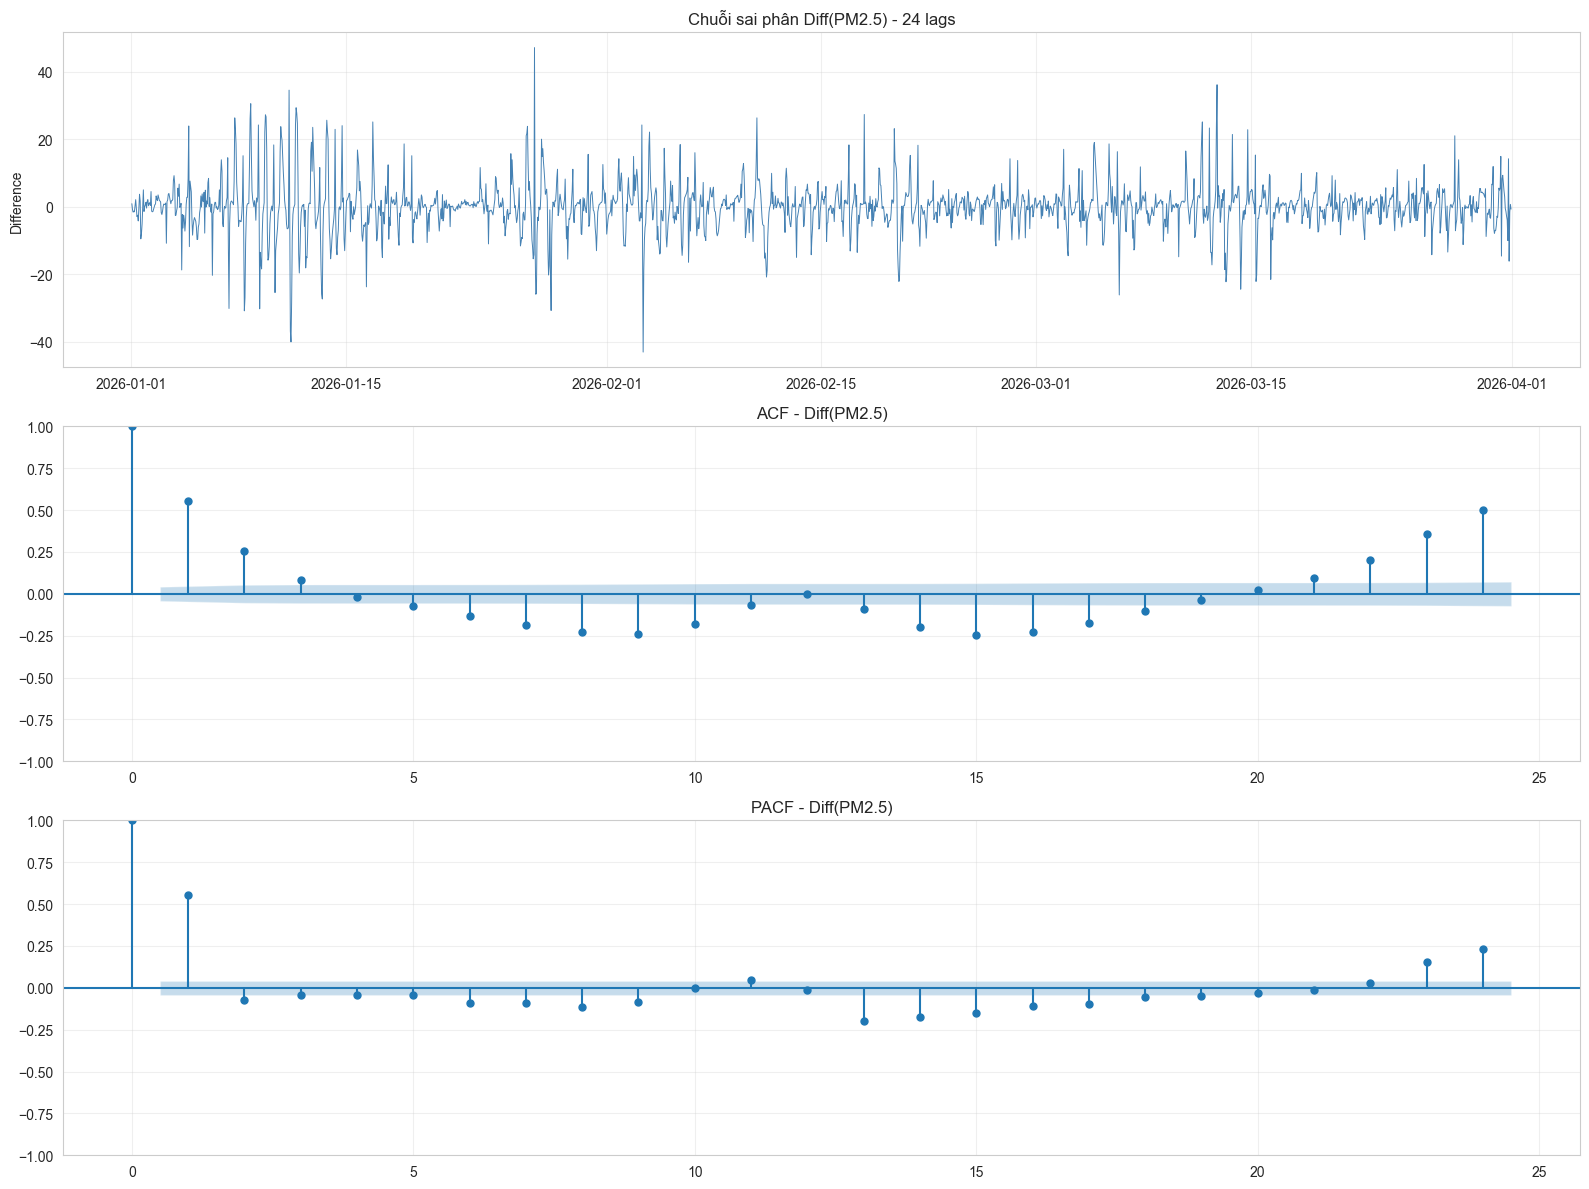

In [17]:
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

axes[0].plot(pm25_diff.index, pm25_diff.values, color='steelblue', linewidth=0.7)
axes[0].set_title('Chuỗi sai phân Diff(PM2.5) - 24 lags')
axes[0].set_ylabel('Difference')
axes[0].grid(True, alpha=0.3)
plot_acf(pm25_diff.dropna(), lags=24, ax=axes[1])
axes[1].set_title('ACF - Diff(PM2.5)')
axes[1].grid(True, alpha=0.3)
plot_pacf(pm25_diff.dropna(), lags=24, ax=axes[2], method='ywm')
axes[2].set_title('PACF - Diff(PM2.5)')
axes[2].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

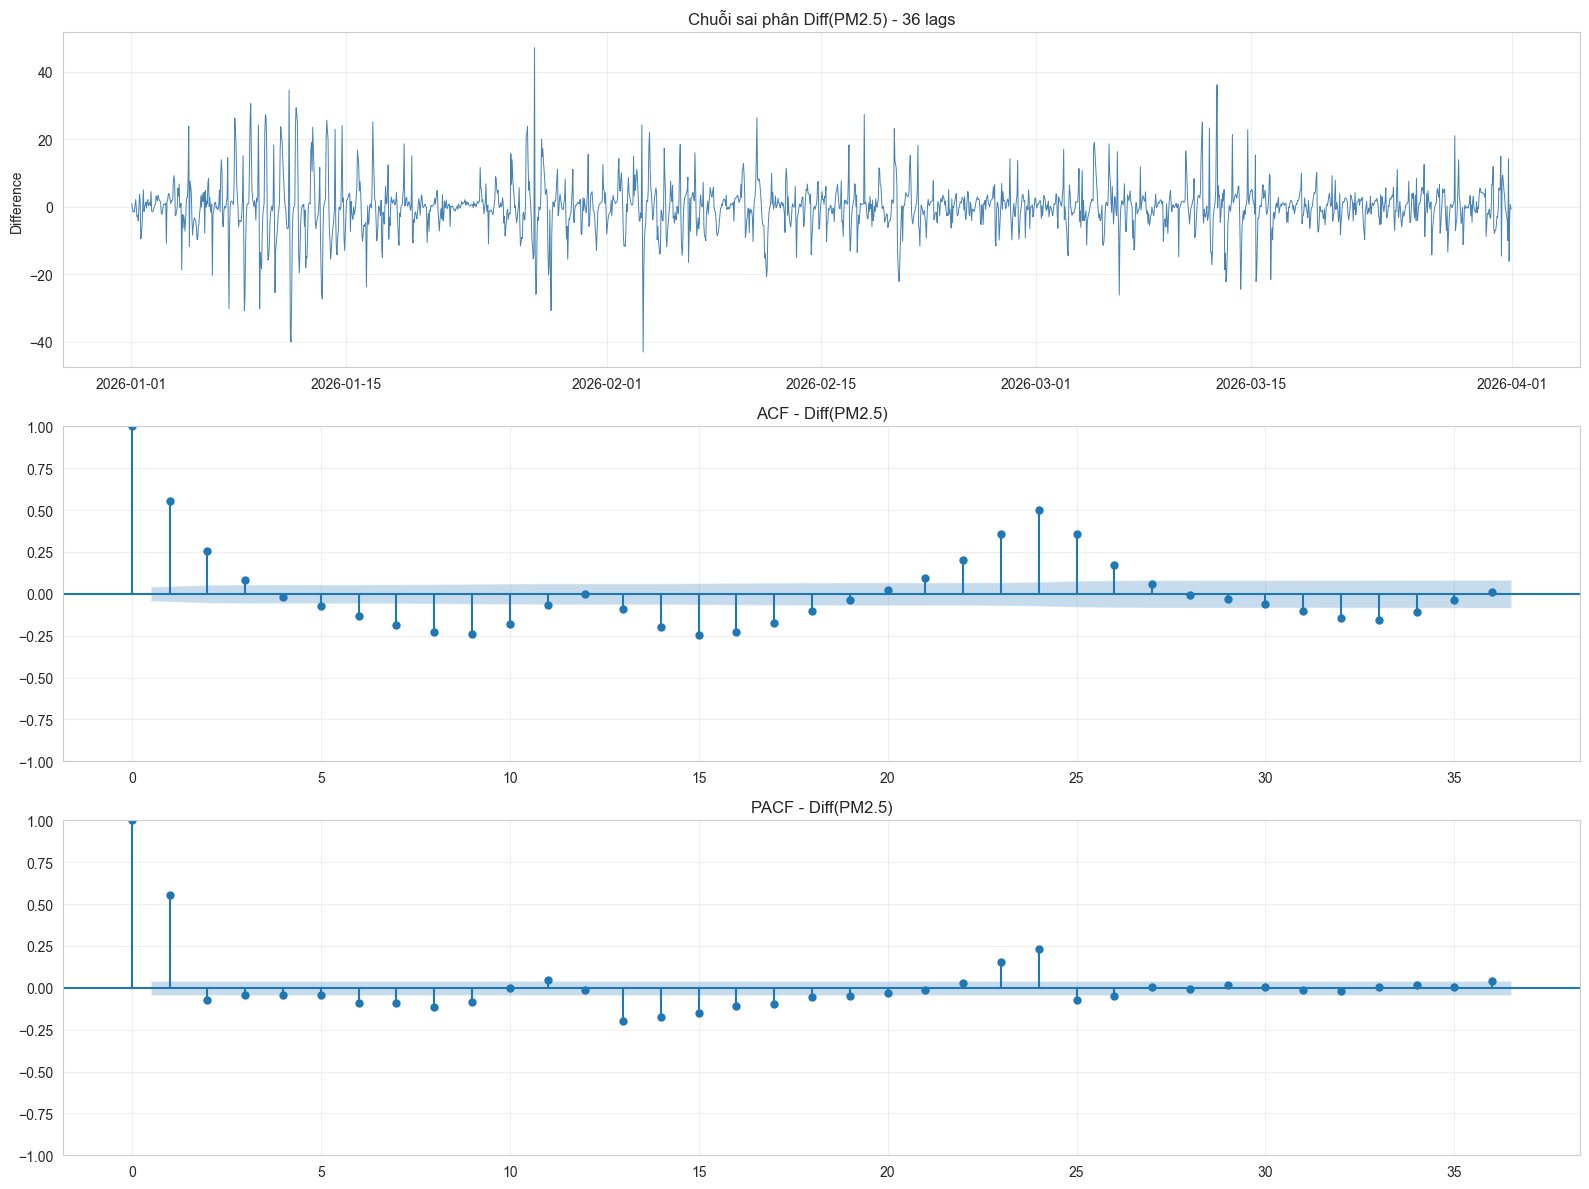

In [18]:
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

axes[0].plot(pm25_diff.index, pm25_diff.values, color='steelblue', linewidth=0.7)
axes[0].set_title('Chuỗi sai phân Diff(PM2.5) - 36 lags')
axes[0].set_ylabel('Difference')
axes[0].grid(True, alpha=0.3)
plot_acf(pm25_diff.dropna(), lags=36, ax=axes[1])
axes[1].set_title('ACF - Diff(PM2.5)')
axes[1].grid(True, alpha=0.3)
plot_pacf(pm25_diff.dropna(), lags=36, ax=axes[2], method='ywm')
axes[2].set_title('PACF - Diff(PM2.5)')
axes[2].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

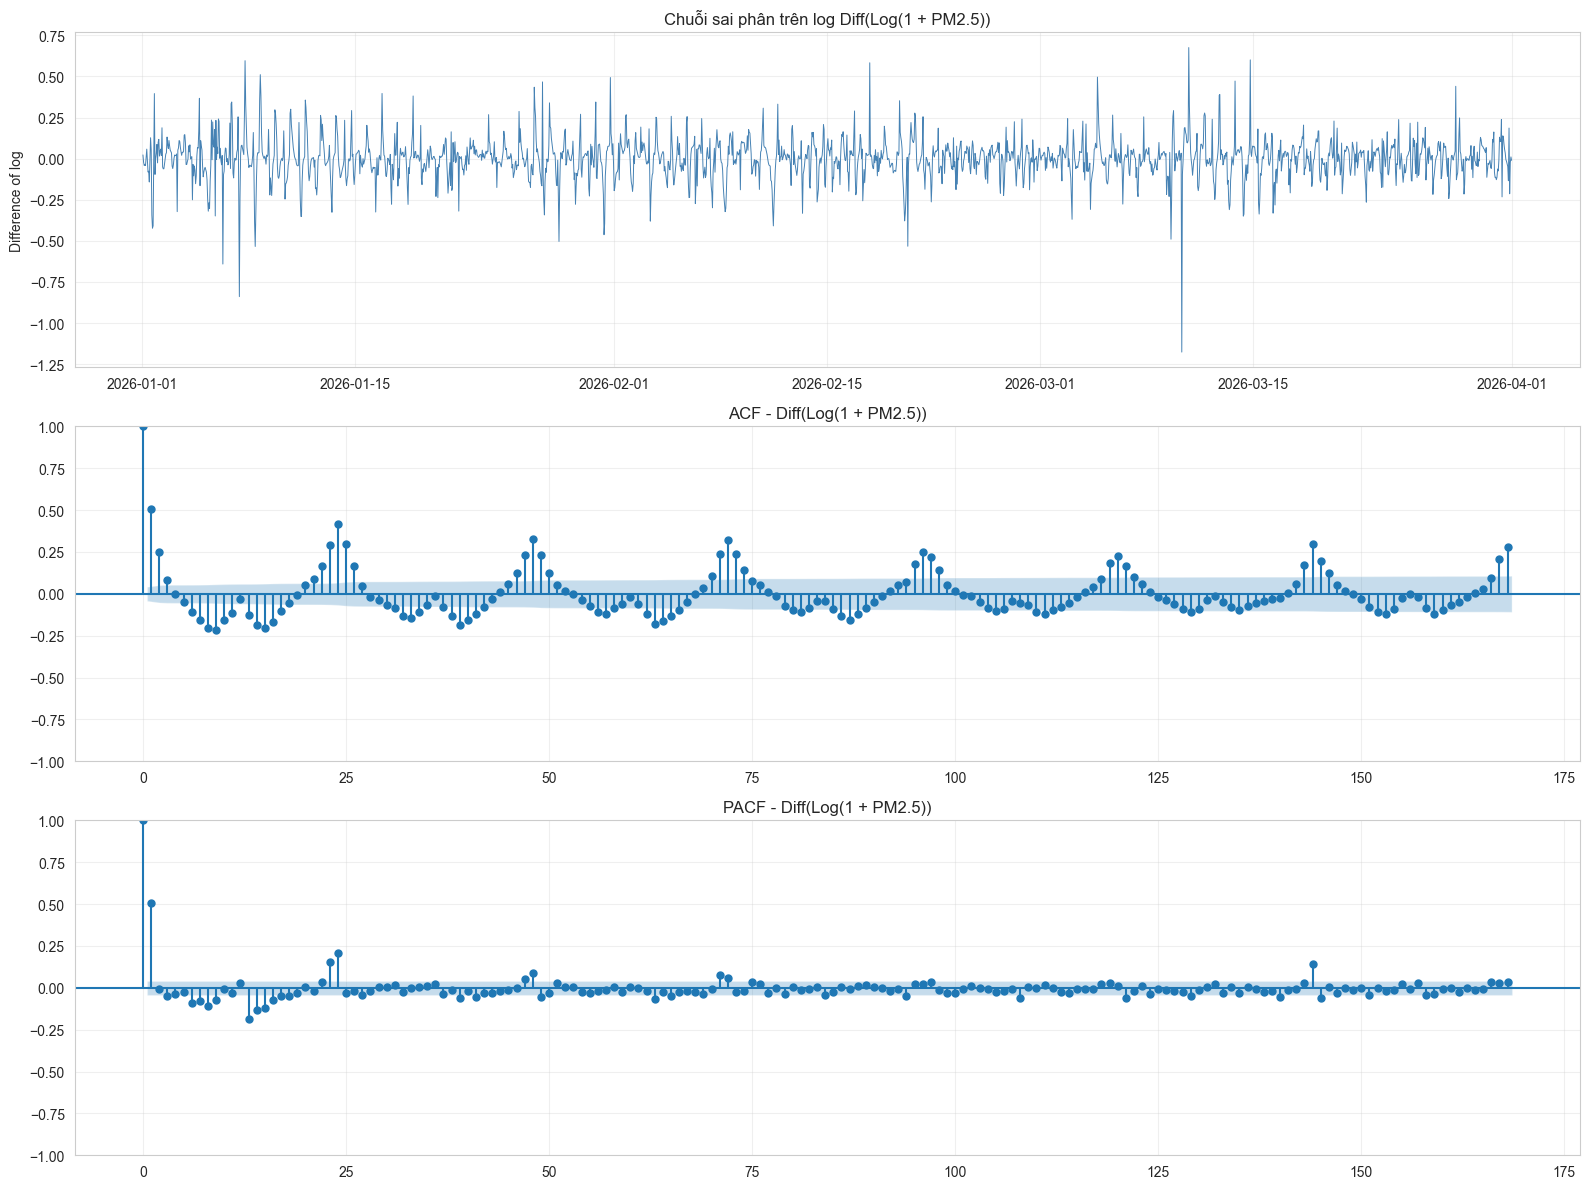

In [19]:
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

axes[0].plot(pm25_log_diff.index, pm25_log_diff.values, color='steelblue', linewidth=0.7)
axes[0].set_title('Chuỗi sai phân trên log Diff(Log(1 + PM2.5))')
axes[0].set_ylabel('Difference of log')
axes[0].grid(True, alpha=0.3)
plot_acf(pm25_log_diff.dropna(), lags=24 * 7, ax=axes[1])
axes[1].set_title('ACF - Diff(Log(1 + PM2.5))')
axes[1].grid(True, alpha=0.3)
plot_pacf(pm25_log_diff.dropna(), lags=24 * 7, ax=axes[2], method='ywm')
axes[2].set_title('PACF - Diff(Log(1 + PM2.5))')
axes[2].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8) MSTL decomposition

Tách chuỗi thành trend, seasonal và residual để xem phần nào là xu hướng dài hạn, phần nào là chu kỳ lặp lại, phần nào là nhiễu.

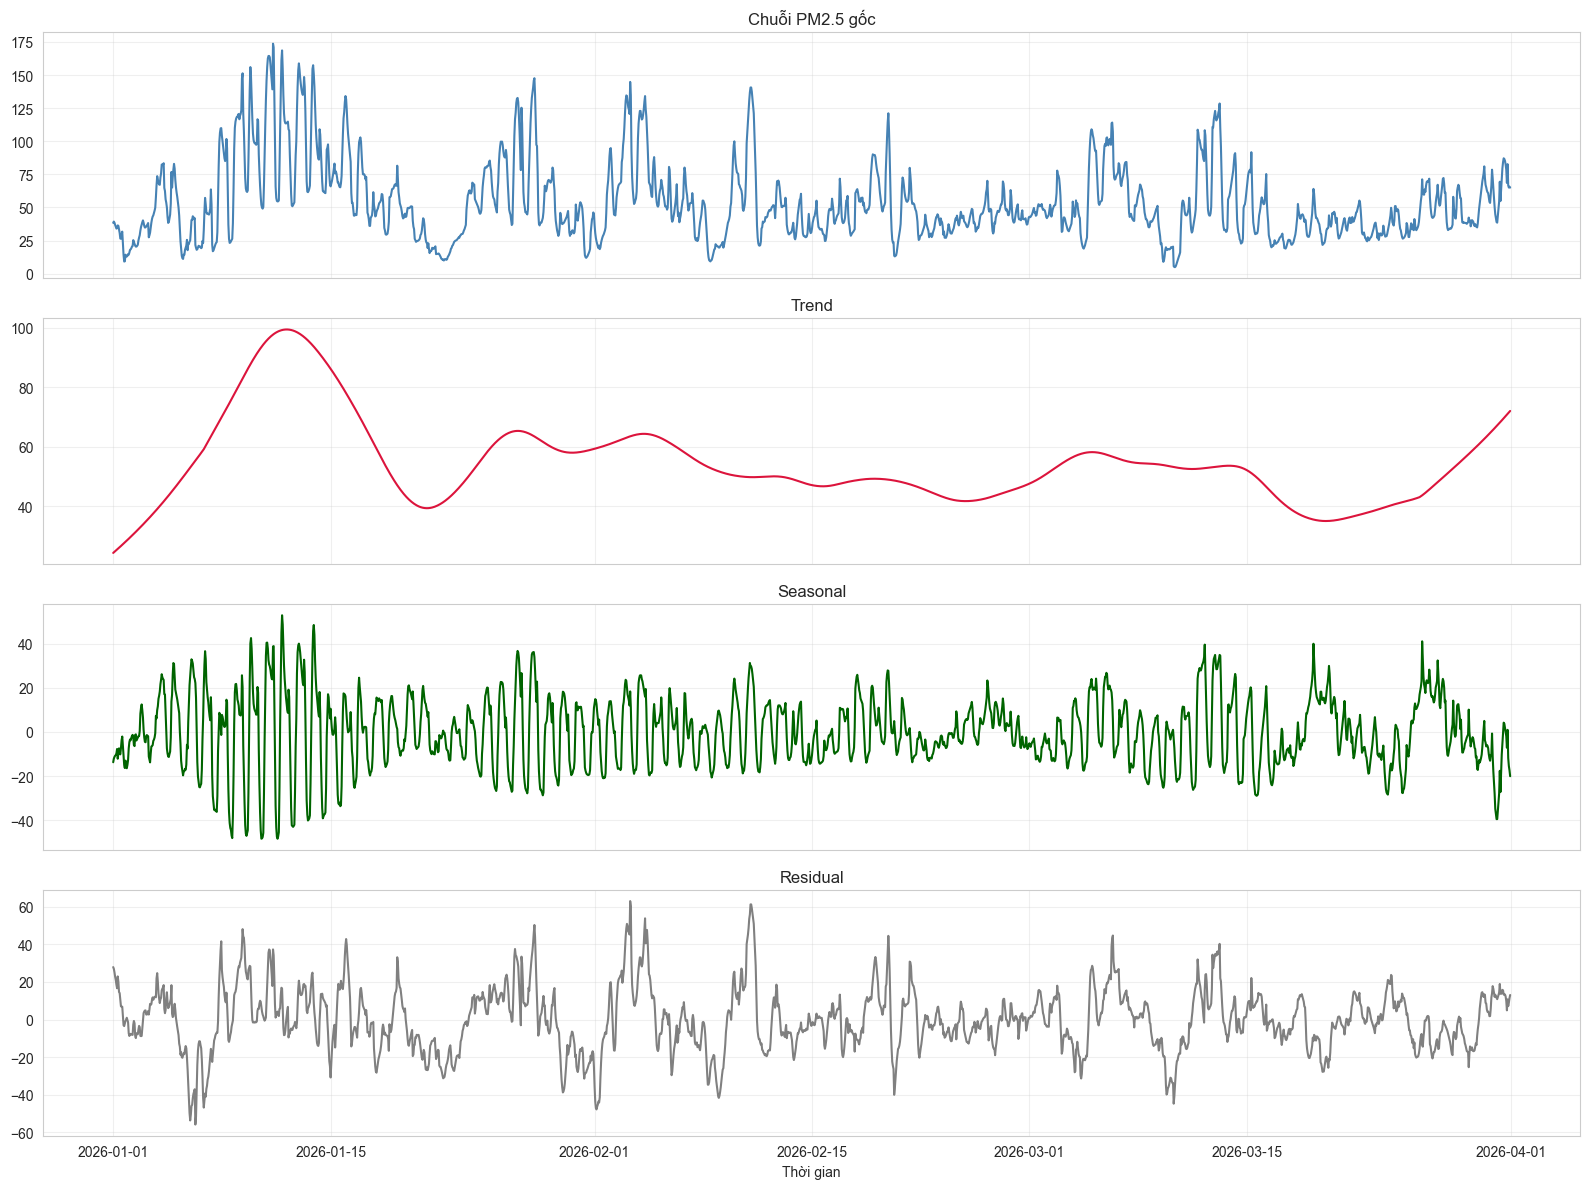

Seasonal strength: 0.5086
Trend strength   : 0.5199


In [20]:
mstl_result = MSTL(pm25_hourly_full, periods=(24, 168)).fit()

if isinstance(mstl_result.seasonal, pd.DataFrame):
    seasonal_component = mstl_result.seasonal.sum(axis=1)
else:
    seasonal_component = mstl_result.seasonal

trend_component = mstl_result.trend
resid_component = mstl_result.resid

fig, axes = plt.subplots(4, 1, figsize=(16, 12), sharex=True)

axes[0].plot(pm25_hourly_full.index, pm25_hourly_full.values, color='steelblue')
axes[0].set_title('Chuỗi PM2.5 gốc')
axes[0].grid(True, alpha=0.3)

axes[1].plot(trend_component.index, trend_component.values, color='crimson')
axes[1].set_title('Trend')
axes[1].grid(True, alpha=0.3)

axes[2].plot(seasonal_component.index, seasonal_component.values, color='darkgreen')
axes[2].set_title('Seasonal')
axes[2].grid(True, alpha=0.3)

axes[3].plot(resid_component.index, resid_component.values, color='gray')
axes[3].set_title('Residual')
axes[3].set_xlabel('Thời gian')
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

seasonal_strength = 1 - np.var(resid_component) / np.var(seasonal_component + resid_component)
trend_strength = 1 - np.var(resid_component) / np.var(trend_component + resid_component)

print('Seasonal strength:', round(float(seasonal_strength), 4))
print('Trend strength   :', round(float(trend_strength), 4))

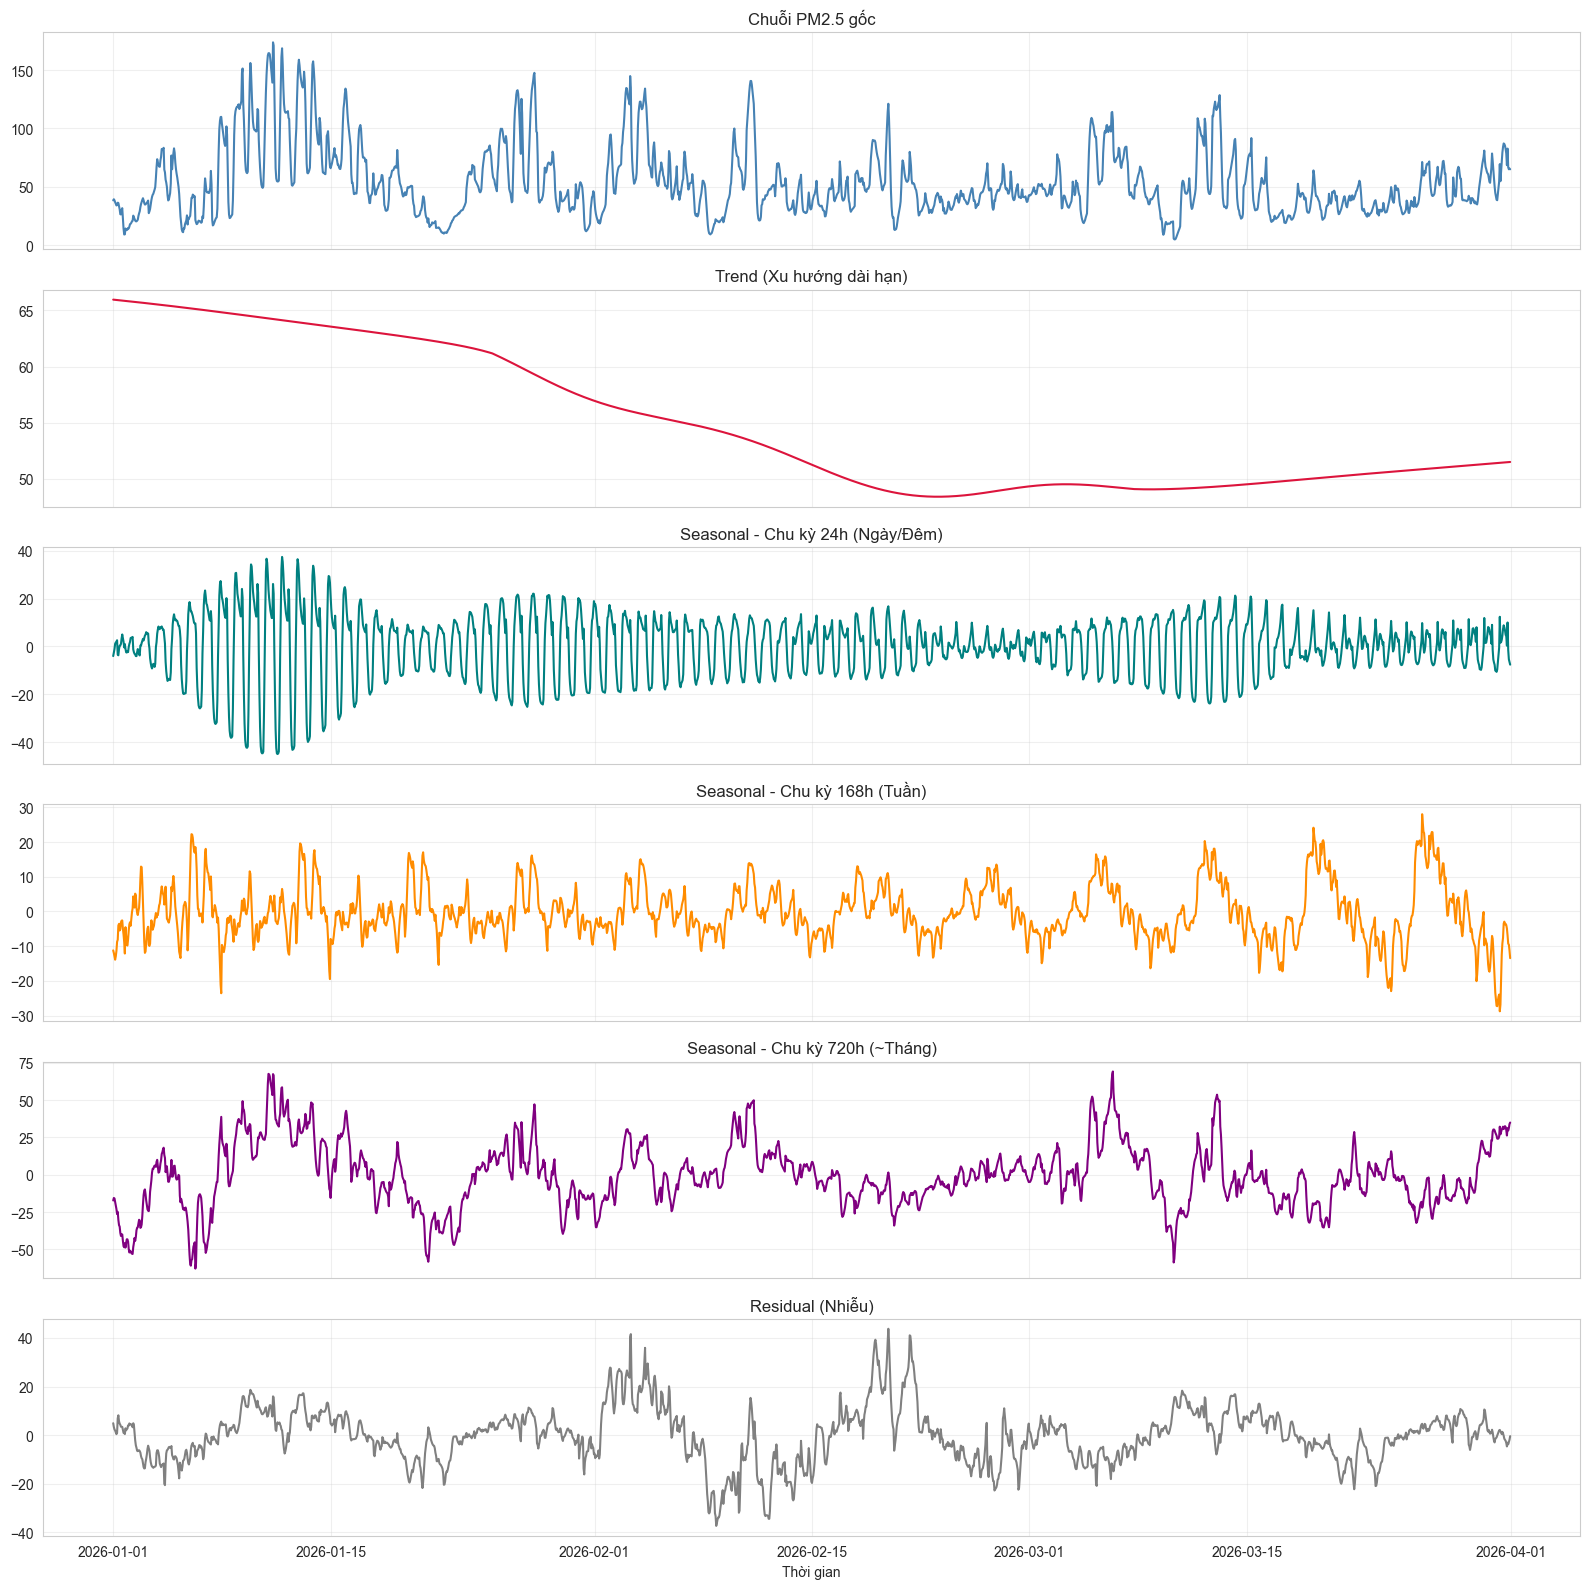

Trend strength       : 0.2379
Seasonal 24h (Ngày)  : 0.5745
Seasonal 168h (Tuần) : 0.3481
Seasonal 720h (Tháng): 0.7808


In [21]:
# 1. Chạy mô hình phân rã với 3 chu kỳ: Ngày (24h), Tuần (168h), Tháng (720h)
mstl_result = MSTL(pm25_hourly_full, periods=(24, 168, 720)).fit()

# Tách riêng các thành phần
trend_component = mstl_result.trend
resid_component = mstl_result.resid

# Lấy từng cột mùa vụ (0: 24h, 1: 168h, 2: 720h)
seasonal_24 = mstl_result.seasonal.iloc[:, 0]
seasonal_168 = mstl_result.seasonal.iloc[:, 1]
seasonal_720 = mstl_result.seasonal.iloc[:, 2]

# 2. Vẽ đồ thị (6 subplots: Gốc, Trend, 3 Mùa vụ, Nhiễu)
fig, axes = plt.subplots(6, 1, figsize=(16, 16), sharex=True)

# Vẽ chuỗi gốc và Trend
axes[0].plot(pm25_hourly_full.index, pm25_hourly_full.values, color='steelblue')
axes[0].set_title('Chuỗi PM2.5 gốc')
axes[0].grid(True, alpha=0.3)

axes[1].plot(trend_component.index, trend_component.values, color='crimson')
axes[1].set_title('Trend (Xu hướng dài hạn)')
axes[1].grid(True, alpha=0.3)

# Vẽ 3 thành phần mùa vụ
axes[2].plot(seasonal_24.index, seasonal_24.values, color='teal')
axes[2].set_title('Seasonal - Chu kỳ 24h (Ngày/Đêm)')
axes[2].grid(True, alpha=0.3)

axes[3].plot(seasonal_168.index, seasonal_168.values, color='darkorange')
axes[3].set_title('Seasonal - Chu kỳ 168h (Tuần)')
axes[3].grid(True, alpha=0.3)

axes[4].plot(seasonal_720.index, seasonal_720.values, color='purple')
axes[4].set_title('Seasonal - Chu kỳ 720h (~Tháng)')
axes[4].grid(True, alpha=0.3)

# Vẽ Residual
axes[5].plot(resid_component.index, resid_component.values, color='gray')
axes[5].set_title('Residual (Nhiễu)')
axes[5].set_xlabel('Thời gian')
axes[5].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ==========================================
# 3. TÍNH STRENGTH RIÊNG BIỆT CHO TỪNG THÀNH PHẦN
# ==========================================

# Viết một hàm nhỏ để tính strength cho gọn gàng
def calculate_strength(component, residual):
    strength = 1 - (np.nanvar(residual) / np.nanvar(component + residual))
    return max(0, float(strength))

# Tính toán
trend_strength = calculate_strength(trend_component, resid_component)
strength_24h = calculate_strength(seasonal_24, resid_component)
strength_168h = calculate_strength(seasonal_168, resid_component)
strength_720h = calculate_strength(seasonal_720, resid_component)

# In kết quả
print(f"Trend strength       : {trend_strength:.4f}")
print(f"Seasonal 24h (Ngày)  : {strength_24h:.4f}")
print(f"Seasonal 168h (Tuần) : {strength_168h:.4f}")
print(f"Seasonal 720h (Tháng): {strength_720h:.4f}")

## 9) Kiểm định tính dừng

Dùng ADF và KPSS để kiểm tra chuỗi có dừng hay không. Thường PM2.5 thô sẽ không dừng vì có trend và seasonality.

In [22]:
def stationarity_report(series, name):
    series = series.dropna()
    print('=' * 70)
    print(name)
    print('=' * 70)

    adf_stat, adf_pvalue, _, _, adf_crit, _ = adfuller(series)
    print('ADF statistic:', round(adf_stat, 4))
    print('ADF p-value   :', round(adf_pvalue, 6))
    print('ADF critical values:', {k: round(v, 4) for k, v in adf_crit.items()})

    try:
        kpss_stat, kpss_pvalue, _, kpss_crit = kpss(series, regression='c', nlags='auto')
        print('KPSS statistic:', round(kpss_stat, 4))
        print('KPSS p-value   :', round(kpss_pvalue, 6))
        print('KPSS critical values:', {k: round(v, 4) for k, v in kpss_crit.items()})
    except Exception as e:
        print('KPSS không chạy được:', e)

    if adf_pvalue < 0.05:
        print('Kết luận ADF: có xu hướng dừng')
    else:
        print('Kết luận ADF: chưa đủ bằng chứng để nói chuỗi dừng')
    print()

stationarity_report(pm25_hourly_full, 'Chuỗi PM2.5 gốc theo giờ')
stationarity_report(pm25_hourly_full.resample('D').mean(), 'Chuỗi PM2.5 trung bình theo ngày')

Chuỗi PM2.5 gốc theo giờ
ADF statistic: -4.437
ADF p-value   : 0.000255
ADF critical values: {'1%': np.float64(-3.4334), '5%': np.float64(-2.8629), '10%': np.float64(-2.5675)}
KPSS statistic: 0.7308
KPSS p-value   : 0.010747
KPSS critical values: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}
Kết luận ADF: có xu hướng dừng

Chuỗi PM2.5 trung bình theo ngày
ADF statistic: -3.0104
ADF p-value   : 0.03393
ADF critical values: {'1%': np.float64(-3.5107), '5%': np.float64(-2.8966), '10%': np.float64(-2.5855)}
KPSS statistic: 0.3213
KPSS p-value   : 0.1
KPSS critical values: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}
Kết luận ADF: có xu hướng dừng



In [23]:
stationarity_report(pm25_diff, 'Chuỗi sai phân Diff(PM2.5)')
stationarity_report(pm25_log_diff, 'Chuỗi Diff(Log(1 + PM2.5))')

Chuỗi sai phân Diff(PM2.5)
ADF statistic: -10.6091
ADF p-value   : 0.0
ADF critical values: {'1%': np.float64(-3.4334), '5%': np.float64(-2.8629), '10%': np.float64(-2.5675)}
KPSS statistic: 0.0052
KPSS p-value   : 0.1
KPSS critical values: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}
Kết luận ADF: có xu hướng dừng

Chuỗi Diff(Log(1 + PM2.5))
ADF statistic: -9.6541
ADF p-value   : 0.0
ADF critical values: {'1%': np.float64(-3.4334), '5%': np.float64(-2.8629), '10%': np.float64(-2.5675)}
KPSS statistic: 0.0058
KPSS p-value   : 0.1
KPSS critical values: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}
Kết luận ADF: có xu hướng dừng



## 10) Rolling statistics

Rolling mean và rolling std giúp xem chuỗi có ổn định hay không. Nếu các đường này thay đổi nhiều thì chuỗi không ổn định.

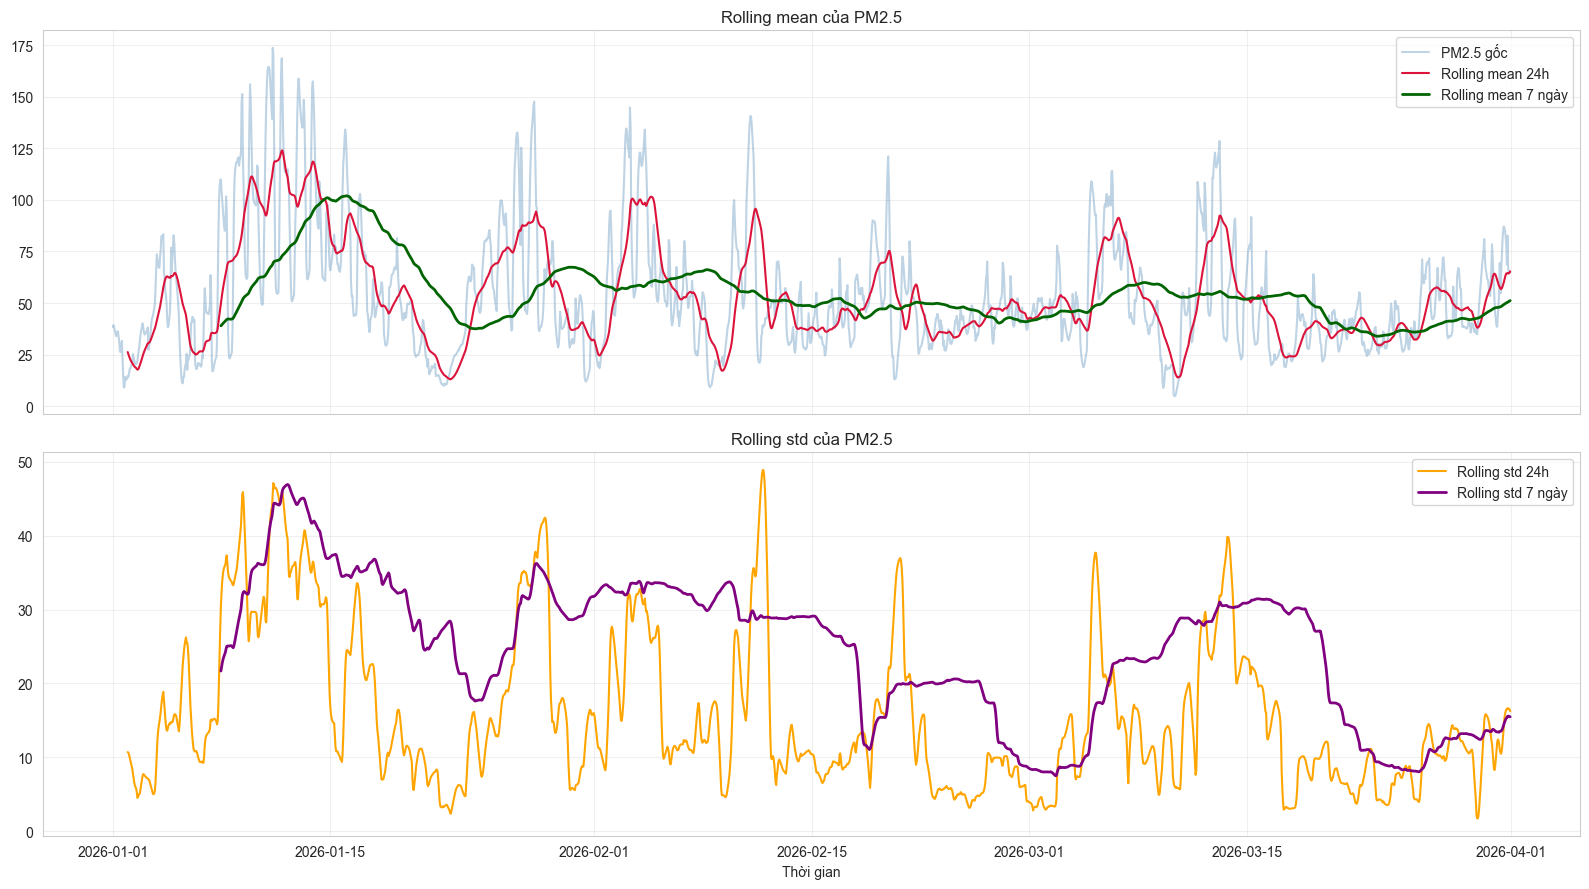

In [24]:
rolling_24h_mean = pm25_hourly_full.rolling(window=24).mean()
rolling_24h_std = pm25_hourly_full.rolling(window=24).std()
rolling_7d_mean = pm25_hourly_full.rolling(window=24 * 7).mean()
rolling_7d_std = pm25_hourly_full.rolling(window=24 * 7).std()

fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharex=True)

axes[0].plot(pm25_hourly_full.index, pm25_hourly_full.values, color='steelblue', alpha=0.35, label='PM2.5 gốc')
axes[0].plot(rolling_24h_mean.index, rolling_24h_mean.values, color='crimson', linewidth=1.5, label='Rolling mean 24h')
axes[0].plot(rolling_7d_mean.index, rolling_7d_mean.values, color='darkgreen', linewidth=2, label='Rolling mean 7 ngày')
axes[0].set_title('Rolling mean của PM2.5')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(rolling_24h_std.index, rolling_24h_std.values, color='orange', linewidth=1.5, label='Rolling std 24h')
axes[1].plot(rolling_7d_std.index, rolling_7d_std.values, color='purple', linewidth=2, label='Rolling std 7 ngày')
axes[1].set_title('Rolling std của PM2.5')
axes[1].set_xlabel('Thời gian')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 11) Tách các giai đoạn PM2.5 cao bất thường

Ta lấy các đoạn liên tiếp có PM2.5 cao để xem chúng xuất hiện vào tháng nào, kéo dài bao lâu và có pattern lặp lại không.

,start_time,end_time,duration_hours,max_pm25,mean_pm25,start_month,duration_days
5,2026-01-09 17:00:00,2026-01-10 10:00:00,18,156.0,110.455556,2026-01,0.750000
7,2026-01-11 17:00:00,2026-01-12 10:00:00,18,168.6,118.450000,2026-01,0.750000
9,2026-01-13 17:00:00,2026-01-14 10:00:00,18,157.4,112.344444,2026-01,0.750000
22,2026-02-03 18:00:00,2026-02-04 11:00:00,18,134.1,113.938889,2026-02,0.750000
6,2026-01-10 18:00:00,2026-01-11 10:00:00,17,173.7,144.494118,2026-01,0.708333
8,2026-01-12 18:00:00,2026-01-13 10:00:00,17,158.8,133.417647,2026-01,0.708333
4,2026-01-08 19:00:00,2026-01-09 11:00:00,17,151.3,118.341176,2026-01,0.708333
33,2026-03-05 18:00:00,2026-03-06 10:00:00,17,114.1,98.411765,2026-03,0.708333
36,2026-03-11 19:00:00,2026-03-12 10:00:00,16,108.7,95.237500,2026-03,0.666667
21,2026-02-02 18:00:00,2026-02-03 09:00:00,16,144.8,117.081250,2026-02,0.666667


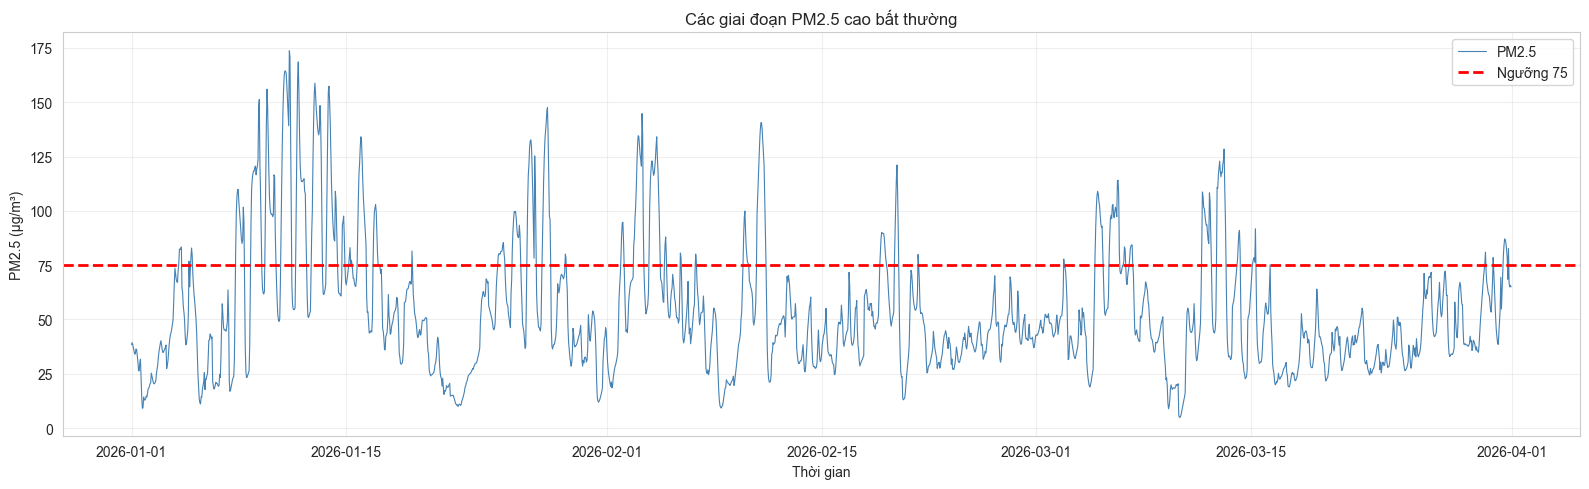

In [25]:
high_threshold = 75
high_flag = pm25_hourly_full >= high_threshold
episode_id = (high_flag != high_flag.shift()).cumsum()

episode_df = pd.DataFrame({
    'time': pm25_hourly_full.index,
    'pm25': pm25_hourly_full.values,
    'is_high': high_flag.values,
    'episode_id': episode_id.values
})

episode_summary = episode_df[episode_df['is_high']].groupby('episode_id').agg(
    start_time=('time', 'first'),
    end_time=('time', 'last'),
    duration_hours=('time', 'size'),
    max_pm25=('pm25', 'max'),
    mean_pm25=('pm25', 'mean')
).reset_index(drop=True)

if not episode_summary.empty:
    episode_summary['start_month'] = episode_summary['start_time'].dt.to_period('M').astype(str)
    episode_summary['duration_days'] = episode_summary['duration_hours'] / 24
    display(episode_summary.sort_values('duration_hours', ascending=False).head(15))
    episode_summary.to_csv(data_dir / 'PM25_2026_Q1_high_episodes.csv', index=False)
else:
    print('Không phát hiện episode PM2.5 cao theo ngưỡng đã chọn.')

plt.figure(figsize=(16, 5))
plt.plot(pm25_hourly_full.index, pm25_hourly_full.values, color='steelblue', linewidth=0.8, label='PM2.5')
plt.axhline(high_threshold, color='red', linestyle='--', linewidth=2, label=f'Ngưỡng {high_threshold}')
plt.title('Các giai đoạn PM2.5 cao bất thường')
plt.xlabel('Thời gian')
plt.ylabel('PM2.5 (µg/m³)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 12) Tương quan và lagged correlation với biến ngoại sinh

Xem biến nào liên hệ mạnh với PM2.5 cùng thời điểm, rồi kiểm tra tương quan trễ để xem biến nào đi trước hay đi sau PM2.5.

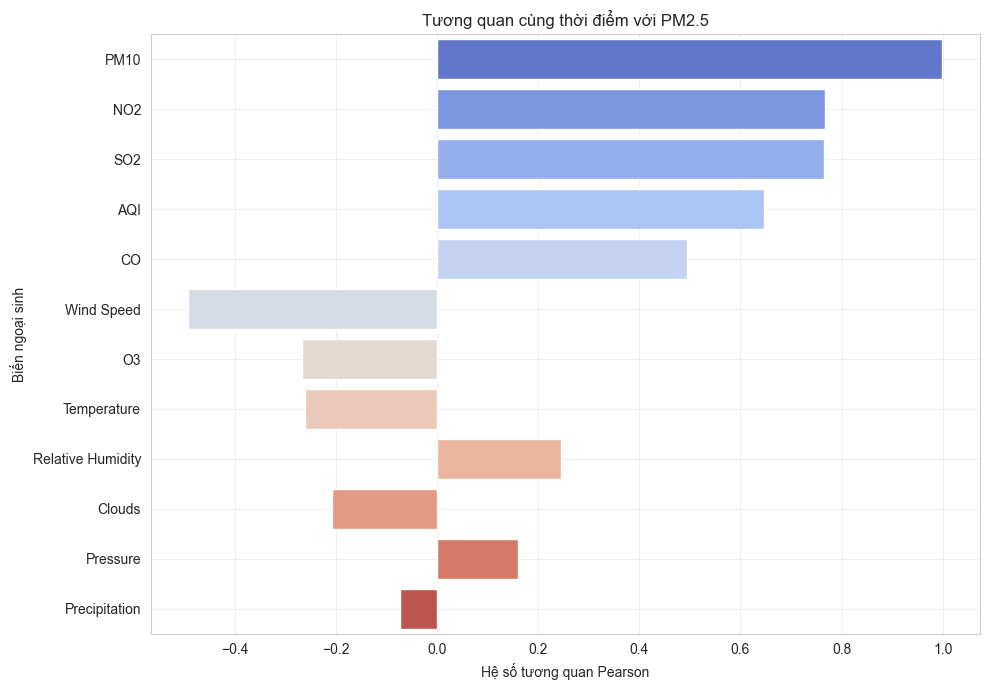

,correlation
PM10,0.998987
NO2,0.766928
SO2,0.764183
AQI,0.646895
CO,0.494787
Wind Speed,-0.491189
O3,-0.266012
Temperature,-0.261283
Relative Humidity,0.245623
Clouds,-0.206878


In [26]:
exogenous_cols = ['CO', 'NO2', 'O3', 'PM10', 'SO2', 'Clouds', 'Precipitation', 'Pressure', 'Relative Humidity', 'Temperature', 'Wind Speed', 'AQI']
corr_df = df_q1_2026[exogenous_cols + ['PM25']].corr(numeric_only=True)
pm25_corr = corr_df['PM25'].drop('PM25').sort_values(key=lambda s: s.abs(), ascending=False)

plt.figure(figsize=(10, 7))
sns.barplot(x=pm25_corr.values, y=pm25_corr.index, palette='coolwarm')
plt.title('Tương quan cùng thời điểm với PM2.5')
plt.xlabel('Hệ số tương quan Pearson')
plt.ylabel('Biến ngoại sinh')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

display(pm25_corr.to_frame('correlation'))

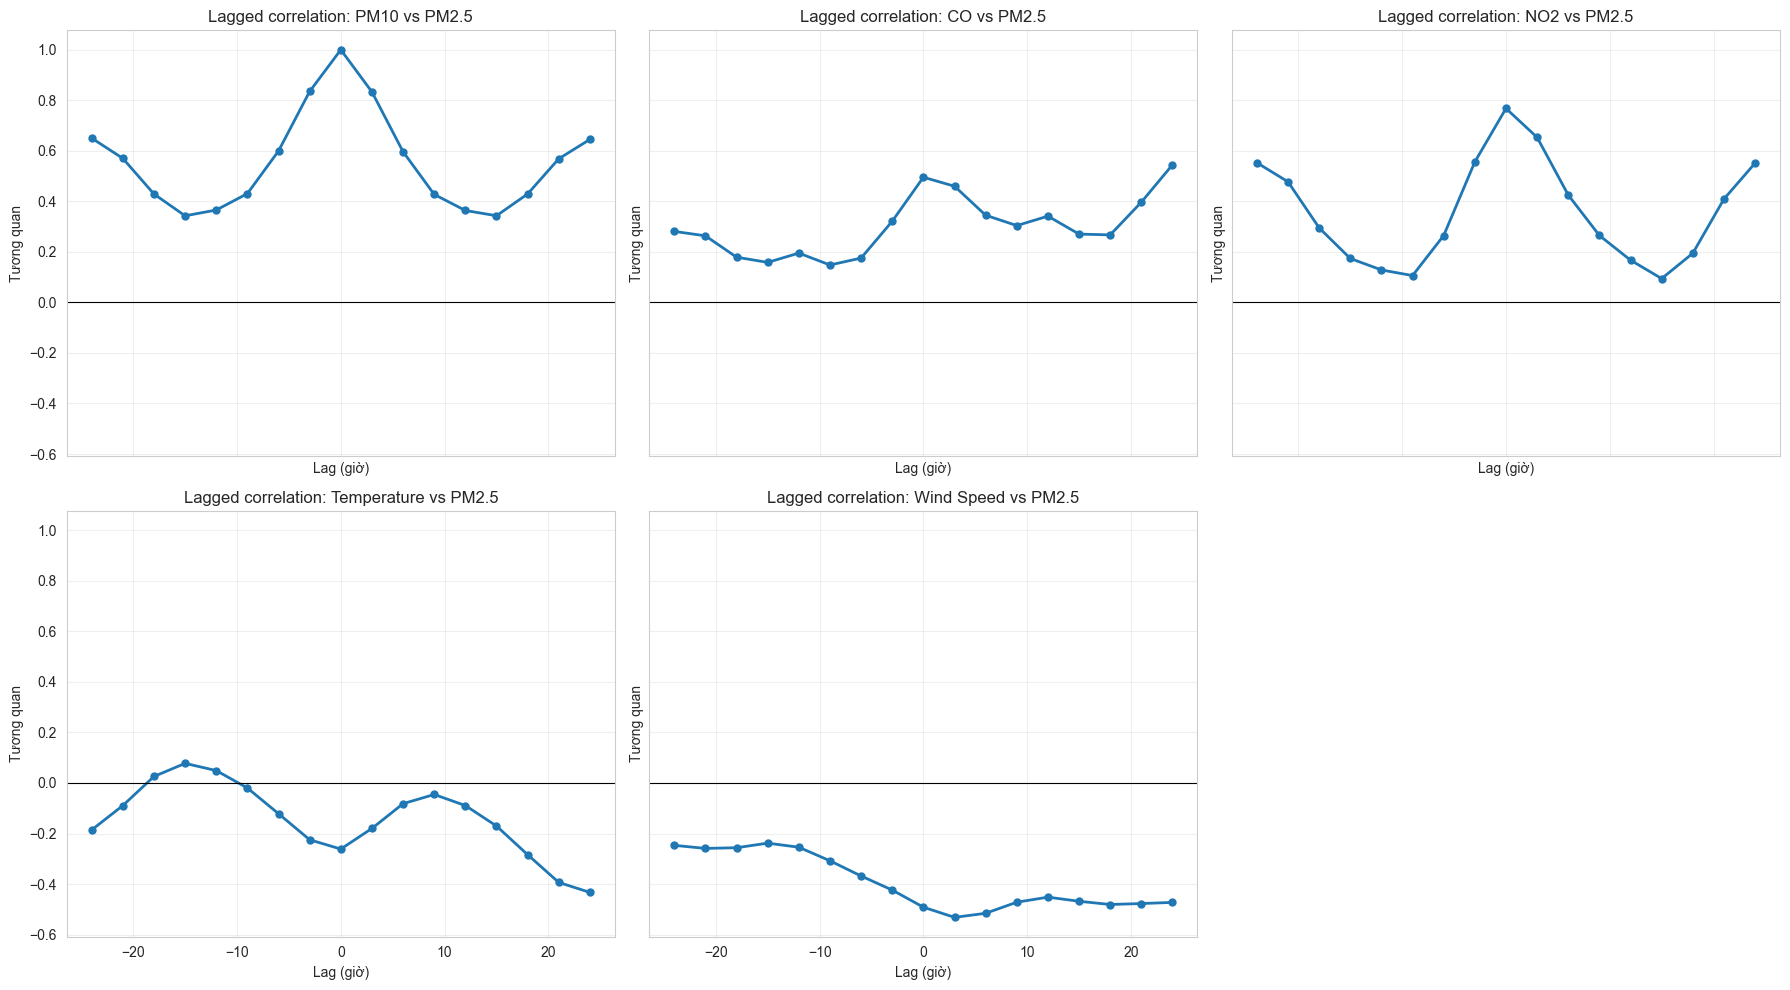

Lag âm: biến đó thay đổi trước PM2.5
Lag dương: biến đó thay đổi sau PM2.5
Lag 0: tương quan cùng thời điểm


In [27]:
def lagged_correlation(series_x, series_y, lags):
    results = []
    for lag in lags:
        shifted = series_x.shift(lag)
        temp = pd.concat([series_y, shifted], axis=1).dropna()
        if len(temp) > 2:
            corr_value = temp.iloc[:, 0].corr(temp.iloc[:, 1])
        else:
            corr_value = np.nan
        results.append({'lag': lag, 'corr': corr_value})
    return pd.DataFrame(results)

lags = list(range(-24, 25, 3))
lag_corr_tables = {}

for col in ['PM10', 'CO', 'NO2', 'Temperature', 'Wind Speed']:
    lag_corr_tables[col] = lagged_correlation(df_q1_2026[col], df_q1_2026['PM25'], lags)

fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=True, sharey=True)
axes = axes.flatten()

for ax, col in zip(axes, ['PM10', 'CO', 'NO2', 'Temperature', 'Wind Speed']):
    temp = lag_corr_tables[col]
    ax.plot(temp['lag'], temp['corr'], marker='o', linewidth=2, markersize=5)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title(f'Lagged correlation: {col} vs PM2.5')
    ax.set_xlabel('Lag (giờ)')
    ax.set_ylabel('Tương quan')
    ax.grid(True, alpha=0.3)

axes[-1].axis('off')
plt.tight_layout()
plt.show()

print('Lag âm: biến đó thay đổi trước PM2.5')
print('Lag dương: biến đó thay đổi sau PM2.5')
print('Lag 0: tương quan cùng thời điểm')

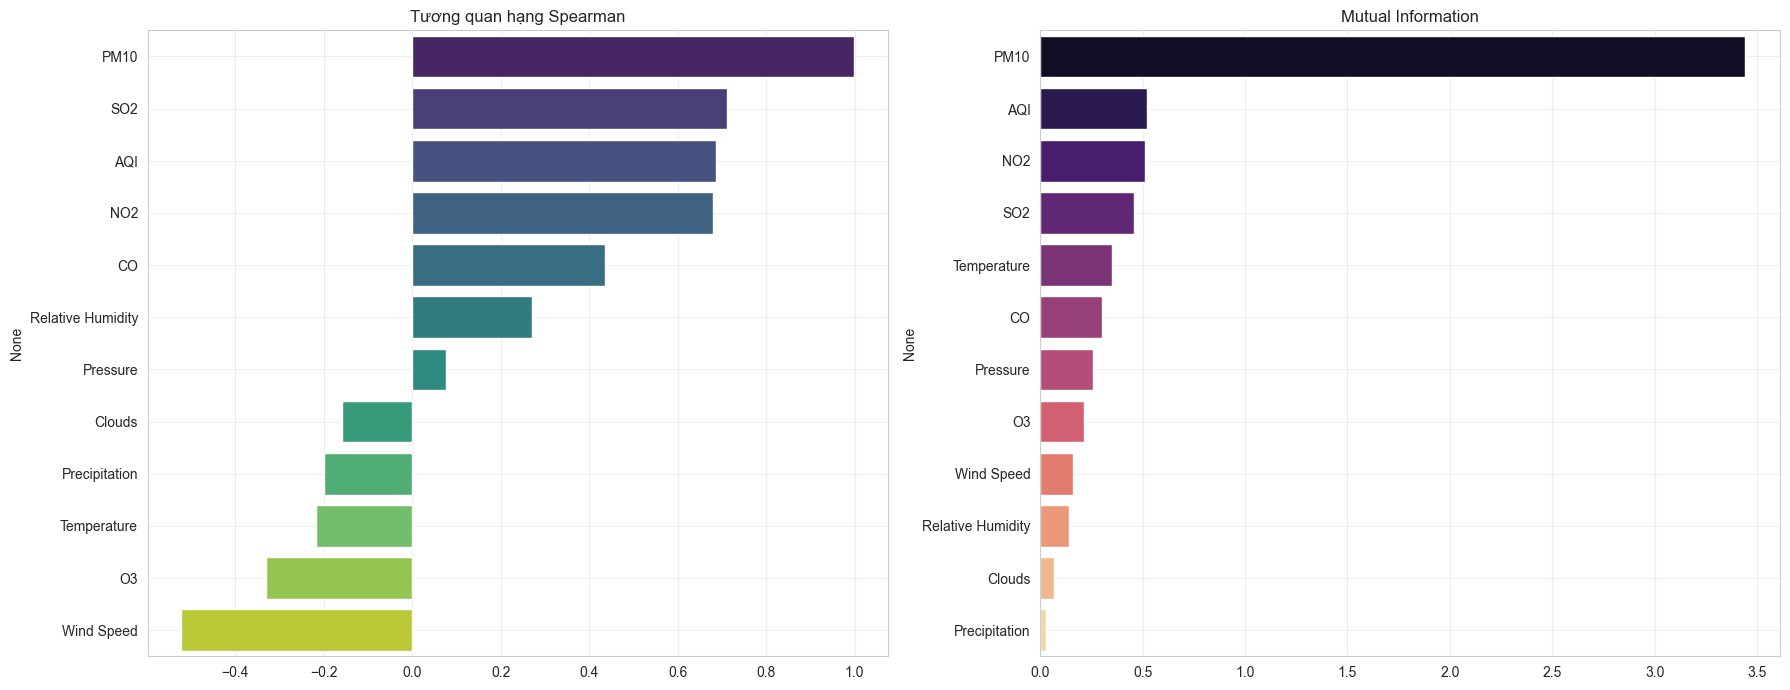

,Pearson,Spearman,Mutual Info
PM10,0.998987,0.998363,3.440159
AQI,0.646895,0.686645,0.520929
NO2,0.766928,0.679119,0.512399
SO2,0.764183,0.710882,0.456557
Temperature,-0.261283,-0.218604,0.349816
CO,0.494787,0.435582,0.303126
Pressure,0.159948,0.077174,0.256851
O3,-0.266012,-0.330710,0.213935
Wind Speed,-0.491189,-0.522154,0.161304
Relative Humidity,0.245623,0.270737,0.138107


In [28]:
spearman_corr = df_q1_2026[exogenous_cols + ['PM25']].corr(method='spearman')['PM25'].drop('PM25')
df_mi = df_q1_2026[exogenous_cols + ['PM25']].dropna()
mi_scores = mutual_info_regression(df_mi[exogenous_cols], df_mi['PM25'], random_state=42)
mi_series = pd.Series(mi_scores, index=exogenous_cols).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.barplot(x=spearman_corr.sort_values(ascending=False).values, y=spearman_corr.sort_values(ascending=False).index, palette='viridis', ax=axes[0])
axes[0].set_title('Tương quan hạng Spearman')
axes[0].grid(True, alpha=0.3)

sns.barplot(x=mi_series.values, y=mi_series.index, palette='magma', ax=axes[1])
axes[1].set_title('Mutual Information')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

comparison_df = pd.DataFrame({
    'Pearson': pm25_corr,
    'Spearman': spearman_corr,
    'Mutual Info': mi_series
}).sort_values(by='Mutual Info', ascending=False)
display(comparison_df)

# Phân loại PM2.5 theo tiêu chuẩn

> **WHO PM2.5 (µg/m³) Recommended Guidelines as of 2024: 0-5.0**

| US AQI Category | US AQI Level | PM2.5 (µg/m³) | Health Recommendation (for 24 hour exposure) |
| :--- | :--- | :--- | :--- |
| **Good** (Tốt) | 0-50 | 0-9.0 | Air quality is satisfactory and poses little or no risk. |
| **Moderate** (Trung bình) | 51-100 | 9.1-35.4 | Sensitive individuals should avoid outdoor activity as they may experience respiratory symptoms. |
| **Unhealthy for Sensitive Groups** (Kém) | 101-150 | 35.5-55.4 | General public and sensitive individuals in particular are at risk to experience irritation and respiratory problems. |
| **Unhealthy** (Xấu) | 151-200 | 55.5-125.4 | Increased likelihood of adverse effects and aggravation to the heart and lungs among general public. |
| **Very Unhealthy** (Rất xấu) | 201-300 | 125.5-225.4 | General public will be noticeably affected. Sensitive groups should restrict outdoor activities. |
| **Hazardous** (Nguy hại) | 301+ | 225.5+ | General public at high risk of experiencing strong irritations and adverse health effects. Should avoid outdoor activities. |

In [29]:
# Phân loại PM2.5 theo WHO 2024
def classify_pm25(pm25_value):
    if pm25_value <= 9.0:
        return 'Good'
    elif pm25_value <= 35.4:
        return 'Moderate'
    elif pm25_value <= 55.4:
        return 'Unhealthy for Sensitive Groups'
    elif pm25_value <= 125.4:
        return 'Unhealthy'
    elif pm25_value <= 225.4:
        return 'Very Unhealthy'
    else:
        return 'Hazardous'

In [30]:
# Áp dụng phân loại vào dataframe
df_q1_2026['PM25_Category'] = df_q1_2026['PM25'].apply(classify_pm25)

In [31]:
# # cách 2
# import pandas as pd
# import numpy as np

# # 1. Định nghĩa các mốc cắt (bins) dựa trên cột PM2.5 (µg/m3) trong ảnh
# # Thêm -np.inf ở đầu và np.inf ở cuối để bắt trọn mọi giá trị dù nhỏ hay lớn nhất
# bins = [-np.inf, 9.0, 35.4, 55.4, 125.4, 225.4, np.inf]

# # 2. Định nghĩa tên các nhóm tương ứng (labels)
# labels = [
#     'Good', 
#     'Moderate', 
#     'Unhealthy for Sensitive Groups', 
#     'Unhealthy', 
#     'Very Unhealthy', 
#     'Hazardous'
# ]

# # 3. Tạo cột phân loại mới bằng pd.cut
# # right=True nghĩa là nó sẽ lấy dấu ngoặc vuông ở bên phải (VD: x <= 9.0 thì vào Good)
# df_tet['AQI_Category'] = pd.cut(df_tet['PM25'], bins=bins, labels=labels, right=True)

THỐNG KÊ PM2.5 THEO PHÂN LOẠI WHO 2024
Good                                     :      7 (  0.3%)
Moderate                                 :    589 ( 27.3%)
Unhealthy for Sensitive Groups           :    810 ( 37.5%)
Unhealthy                                :    681 ( 31.5%)
Very Unhealthy                           :     73 (  3.4%)
Hazardous                                :      0 (  0.0%)


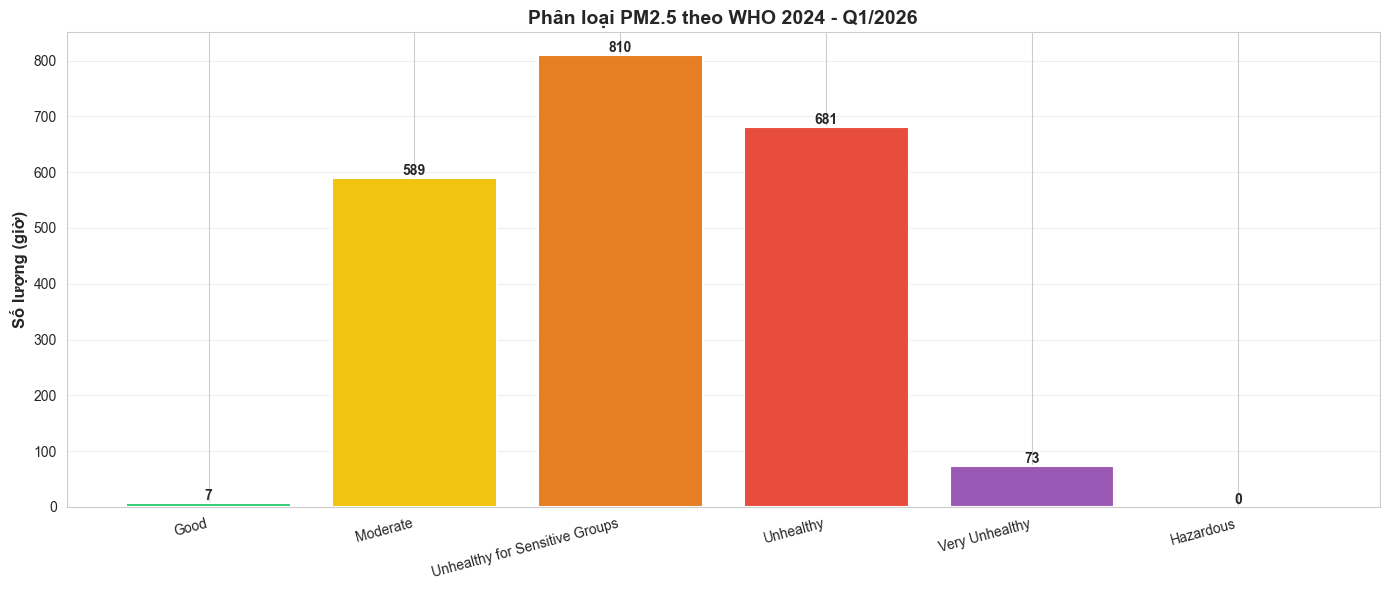

In [32]:
# Thống kê số lượng từng loại
category_counts = df_q1_2026['PM25_Category'].value_counts()
category_order = ['Good', 'Moderate', 'Unhealthy for Sensitive Groups', 
                  'Unhealthy', 'Very Unhealthy', 'Hazardous']
category_counts = category_counts.reindex(category_order, fill_value=0)

print('=' * 80)
print('THỐNG KÊ PM2.5 THEO PHÂN LOẠI WHO 2024')
print('=' * 80)
for category, count in category_counts.items():
    percentage = (count / len(df_q1_2026)) * 100
    print(f'{category:40} : {count:6} ({percentage:5.1f}%)')
print('=' * 80)

# Vẽ biểu đồ
colors = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c', '#9b59b6', '#8b4513']
fig, ax = plt.subplots(figsize=(14, 6))

bars = ax.bar(range(len(category_counts)), category_counts.values, color=colors, linewidth=1.5)
ax.set_xticks(range(len(category_counts)))
ax.set_xticklabels(category_counts.index, rotation=15, ha='right')
ax.set_ylabel('Số lượng (giờ)', fontsize=12, fontweight='bold')
ax.set_title('Phân loại PM2.5 theo WHO 2024 - Q1/2026', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# Thêm số lượng trên từng cột
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}',
            ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

In [33]:
# Thống kê theo tháng
print('\n' + '=' * 80)
print('PHÂN LOẠI PM2.5 THEO THÁNG')
print('=' * 80)
month_category = pd.crosstab(df_q1_2026['month'], df_q1_2026['PM25_Category'], margins=True)
# Chỉ lấy các cột có trong dữ liệu và 'All'
cols_to_display = [col for col in category_order if col in month_category.columns] + ['All']
month_category = month_category[cols_to_display]
display(month_category)


PHÂN LOẠI PM2.5 THEO THÁNG


PM25_Category,Good,Moderate,Unhealthy for Sensitive Groups,Unhealthy,Very Unhealthy,All
month,,,,,,
2026-01,0,199,198,291,56,744
2026-02,0,171,304,181,16,672
2026-03,7,219,308,209,1,744
All,7,589,810,681,73,2160


# Gộp dữ liệu từ 24 điểm 1 ngày thành 1 điểm 1 ngày

In [34]:
# ==========================================
# GỘP DỮ LIỆU THEO NGÀY (RESAMPLING)
# ==========================================

# Đặt 'Local Time' làm index
df_q1_2026_for_daily = df_q1_2026.set_index('Local Time')

# Chỉ lấy các cột dạng số
numeric_cols = df_q1_2026_for_daily.select_dtypes(include=['number']).columns

# Gộp theo ngày ('D') và tính giá trị trung bình (mean)
df_q1_2026_daily = df_q1_2026_for_daily[numeric_cols].resample('D').mean()

# Xóa các hàng bị NaN (nếu có ngày nào đó hoàn toàn không có dữ liệu)
df_q1_2026_daily = df_q1_2026_daily.dropna(subset=['PM25'])

print("Dữ liệu Q1_2026 sau khi gộp theo ngày shape:", df_q1_2026_daily.shape)
df_q1_2026_daily.head(3)

Dữ liệu Q1_2026 sau khi gộp theo ngày shape: (90, 14)


,AQI,CO,NO2,O3,PM10,PM25,SO2,Clouds,Precipitation,Pressure,Relative Humidity,Temperature,Wind Speed,hour
Local Time,,,,,,,,,,,,,,
2026-01-01,103.375000,664.375000,25.891667,62.333333,26.875000,26.275000,30.366667,94.666667,0.191667,1014.554167,87.250000,19.558333,11.850000,11.5
2026-01-02,69.125000,878.083333,22.833333,35.166667,25.516667,25.283333,36.200000,100.000000,0.041667,1021.179167,76.000000,15.708333,11.158333,11.5
2026-01-03,96.083333,766.958333,37.145833,25.875000,45.687500,45.412500,50.358333,96.083333,0.000000,1021.370833,73.708333,15.950000,6.583333,11.5


In [35]:
# Dùng chuỗi đã gộp theo ngày
stationarity_report(df_q1_2026_daily['PM25'], 'Chuỗi PM2.5 trung bình theo ngày - Q1/2026')

Chuỗi PM2.5 trung bình theo ngày - Q1/2026
ADF statistic: -3.0104
ADF p-value   : 0.03393
ADF critical values: {'1%': np.float64(-3.5107), '5%': np.float64(-2.8966), '10%': np.float64(-2.5855)}
KPSS statistic: 0.3213
KPSS p-value   : 0.1
KPSS critical values: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}
Kết luận ADF: có xu hướng dừng



In [36]:
# áp dụng gộp cho train và test, rồi lưu lại
# đã có df_train và df_test từ trước, giờ chỉ cần gộp theo ngày rồi lưu lại
df_q1_2026_train_for_daily = df_train.set_index('Local Time')
# df_q1_2026_test_for_daily = df_test.set_index('Local Time')
numeric_cols_train = df_q1_2026_train_for_daily.select_dtypes(include=['number']).columns

df_train_daily = df_train.set_index('Local Time')[numeric_cols_train].resample('D').mean().dropna(subset=['PM25'])
df_test_daily = df_test.set_index('Local Time')[numeric_cols_train].resample('D').mean().dropna(subset=['PM25'])

# Lưu lại
df_train_daily.to_csv(data_dir / 'PM25_2026_Q1_train_daily.csv')
df_test_daily.to_csv(data_dir / 'PM25_2026_Q1_test_daily.csv')

# thống kê
print("Dữ liệu train sau khi gộp theo ngày shape:", df_train_daily.shape)
print("Dữ liệu test sau khi gộp theo ngày shape:", df_test_daily.shape)

Dữ liệu train sau khi gộp theo ngày shape: (83, 13)
Dữ liệu test sau khi gộp theo ngày shape: (7, 13)


In [37]:
stationarity_report(df_train_daily['PM25'], 'Chuỗi PM2.5 trung bình theo ngày - Q1/2026 - train')

Chuỗi PM2.5 trung bình theo ngày - Q1/2026 - train
ADF statistic: -2.8266
ADF p-value   : 0.054575
ADF critical values: {'1%': np.float64(-3.5183), '5%': np.float64(-2.8999), '10%': np.float64(-2.5872)}
KPSS statistic: 0.3269
KPSS p-value   : 0.1
KPSS critical values: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}
Kết luận ADF: chưa đủ bằng chứng để nói chuỗi dừng



In [38]:
# kiểmđịnhtínhdừngtrêntậptrainđãlấylog
stationarity_report(np.log(df_train_daily['PM25']), 'Chuỗi PM2.5 trung bình theo ngày - Q1/2026 - train')

Chuỗi PM2.5 trung bình theo ngày - Q1/2026 - train
ADF statistic: -5.5151
ADF p-value   : 2e-06
ADF critical values: {'1%': np.float64(-3.5138), '5%': np.float64(-2.8979), '10%': np.float64(-2.5862)}
KPSS statistic: 0.2271
KPSS p-value   : 0.1
KPSS critical values: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}
Kết luận ADF: có xu hướng dừng



In [45]:
stationarity_report(df_train_daily['PM25'].diff().dropna(), 'Chuỗi PM2.5 trung bình theo ngày - Q1/2026 - train')

Chuỗi PM2.5 trung bình theo ngày - Q1/2026 - train
ADF statistic: -6.3518
ADF p-value   : 0.0
ADF critical values: {'1%': np.float64(-3.5183), '5%': np.float64(-2.8999), '10%': np.float64(-2.5872)}
KPSS statistic: 0.0383
KPSS p-value   : 0.1
KPSS critical values: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}
Kết luận ADF: có xu hướng dừng



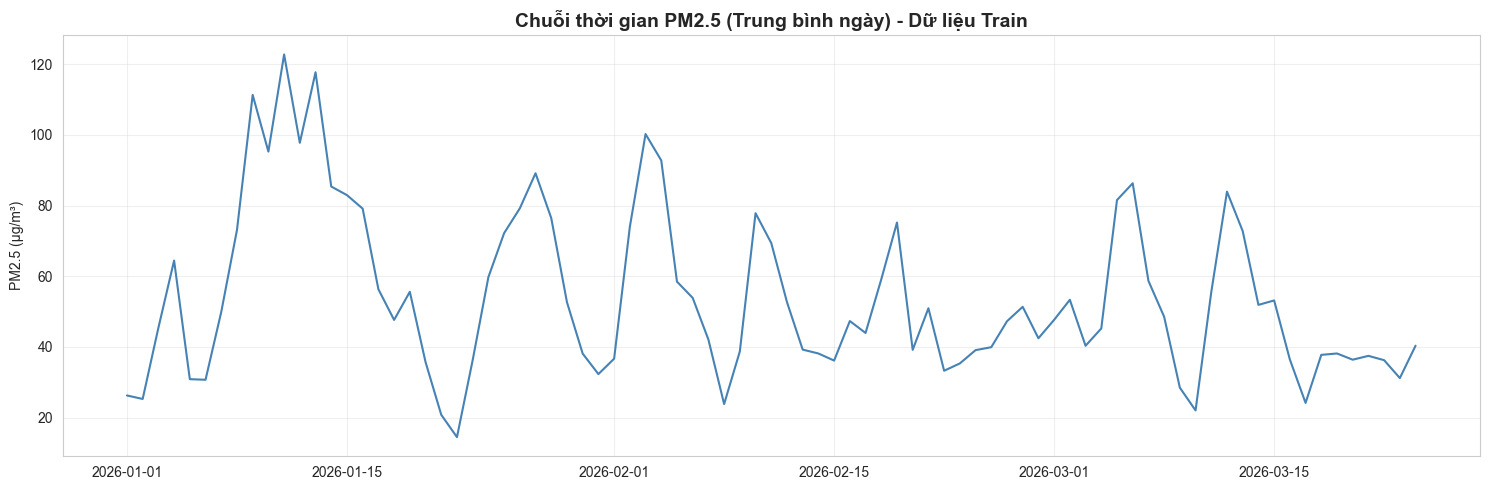

In [39]:
# ==========================================
# VẼ ĐỒ THỊ CHUỖI THỜI GIAN
# ==========================================

fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(15, 5))

# Đồ thị 1: Chuỗi thời gian PM2.5 theo ngày
axes.plot(df_train_daily.index, df_train_daily['PM25'], color='steelblue', linewidth=1.5)
axes.set_title('Chuỗi thời gian PM2.5 (Trung bình ngày) - Dữ liệu Train', fontsize=14, fontweight='bold')
axes.set_ylabel('PM2.5 (µg/m³)')
axes.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

ko cần sai phân vì chuỗi đã dừng :>

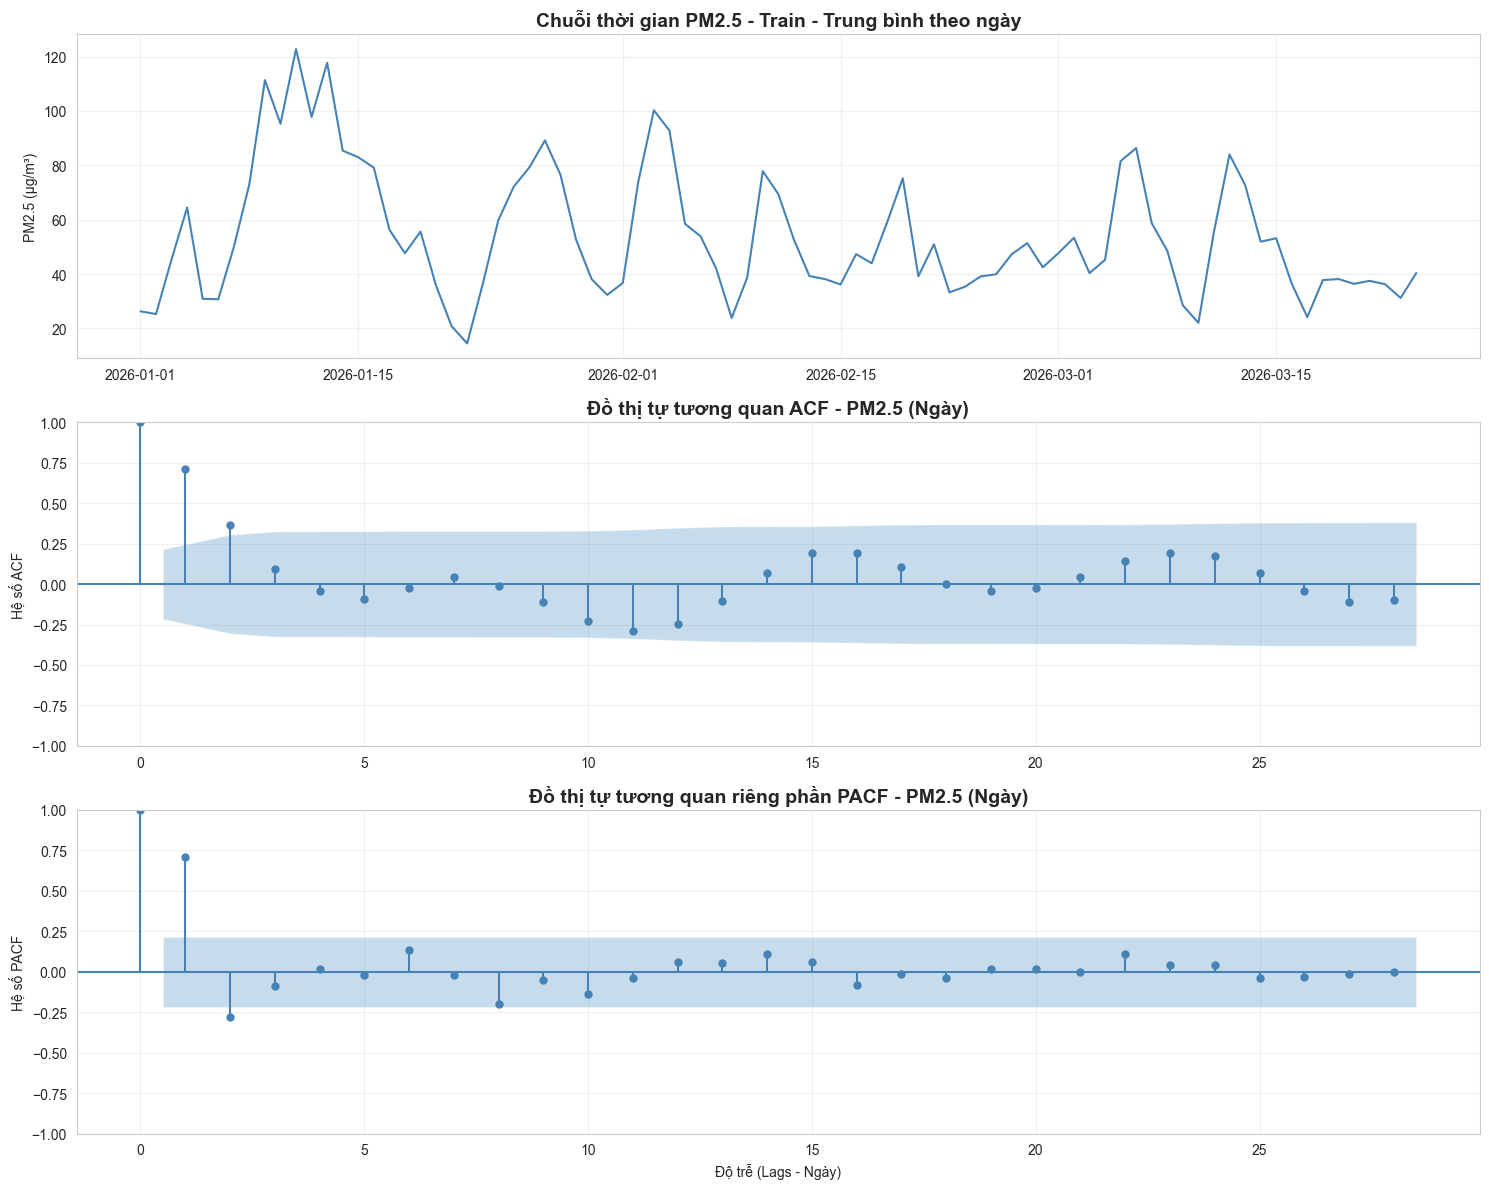

In [40]:
# ==========================================
# VẼ ĐỒ THỊ CHUỖI THỜI GIAN, ACF VÀ PACF CHO DỮ LIỆU ĐÃ GỘP THEO NGÀY KHÔNG LẤY SAI PHÂN
# ==========================================

fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(15, 12))

# Đồ thị 1: Chuỗi thời gian PM2.5
axes[0].plot(df_train_daily.index, df_train_daily['PM25'], color='steelblue', linewidth=1.5)
axes[0].set_title('Chuỗi thời gian PM2.5 - Train - Trung bình theo ngày', fontsize=14, fontweight='bold')
axes[0].set_ylabel('PM2.5 (µg/m³)')
axes[0].grid(True, alpha=0.3)

# Đồ thị 2: Đồ thị tự tương quan ACF
plot_acf(df_train_daily['PM25'], lags=28, ax=axes[1], color='steelblue', vlines_kwargs={'colors':'steelblue'})
axes[1].set_title('Đồ thị tự tương quan ACF - PM2.5 (Ngày)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Hệ số ACF')
axes[1].grid(True, alpha=0.3)

# Đồ thị 3: Đồ thị tự tương quan riêng phần PACF
plot_pacf(df_train_daily['PM25'], lags=28, ax=axes[2], method='ywm', color='steelblue', vlines_kwargs={'colors':'steelblue'})
axes[2].set_title('Đồ thị tự tương quan riêng phần PACF - PM2.5 (Ngày)', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Độ trễ (Lags - Ngày)')
axes[2].set_ylabel('Hệ số PACF')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Gộp dữ liệu từ 24 điểm 1 ngày thành 4 điểm 1 ngày - cụm 6 giờ

In [41]:
# ==========================================
# GỘP DỮ LIỆU THEO CỤM 6 GIỜ (RESAMPLING)
# ==========================================

# Gộp theo cụm 6 giờ ('6h') và tính giá trị trung bình (mean)
df_q1_2026_6h = df_q1_2026_for_daily[numeric_cols].resample('6h').mean()

# Xóa các hàng bị NaN (nếu có cụm 6h nào đó hoàn toàn không có dữ liệu)
df_q1_2026_6h = df_q1_2026_6h.dropna(subset=['PM25'])

print("Dữ liệu Q1_2026 sau khi gộp theo 6h shape:", df_q1_2026_6h.shape)
df_q1_2026_6h.head(3)

Dữ liệu Q1_2026 sau khi gộp theo 6h shape: (360, 14)


,AQI,CO,NO2,O3,PM10,PM25,SO2,Clouds,Precipitation,Pressure,Relative Humidity,Temperature,Wind Speed,hour
Local Time,,,,,,,,,,,,,,
2026-01-01 00:00:00,120.166667,526.333333,29.450000,53.333333,38.033333,37.066667,29.216667,84.500000,0.066667,1011.383333,96.333333,18.866667,9.400000,2.5
2026-01-01 06:00:00,108.500000,671.833333,33.083333,61.333333,33.750000,32.866667,36.266667,98.333333,0.150000,1014.733333,91.666667,19.516667,8.250000,8.5
2026-01-01 12:00:00,97.833333,626.500000,23.683333,74.000000,22.633333,22.250000,29.716667,95.833333,0.300000,1014.516667,78.833333,21.633333,12.633333,14.5


In [42]:
# Dùng chuỗi đã gộp theo 6h
stationarity_report(df_q1_2026_6h['PM25'], 'Chuỗi PM2.5 trung bình theo 6 giờ - Q1/2026')

Chuỗi PM2.5 trung bình theo 6 giờ - Q1/2026
ADF statistic: -4.9474
ADF p-value   : 2.8e-05
ADF critical values: {'1%': np.float64(-3.4491), '5%': np.float64(-2.8698), '10%': np.float64(-2.5712)}
KPSS statistic: 0.4027
KPSS p-value   : 0.075994
KPSS critical values: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}
Kết luận ADF: có xu hướng dừng



In [43]:
df_train_6h = df_train.set_index('Local Time')[numeric_cols_train].resample('6h').mean().dropna(subset=['PM25'])
df_test_6h = df_test.set_index('Local Time')[numeric_cols_train].resample('6h').mean().dropna(subset=['PM25'])

# Lưu lại
df_train_6h.to_csv(data_dir / 'PM25_2026_Q1_train_6h.csv')
df_test_6h.to_csv(data_dir / 'PM25_2026_Q1_test_6h.csv')

# thống kê
print("Dữ liệu train sau khi gộp theo 6h shape:", df_train_6h.shape)
print("Dữ liệu test sau khi gộp theo 6h shape:", df_test_6h.shape)

Dữ liệu train sau khi gộp theo 6h shape: (332, 13)
Dữ liệu test sau khi gộp theo 6h shape: (28, 13)


In [44]:
stationarity_report(df_train_6h['PM25'], 'Chuỗi PM2.5 trung bình theo 6h - Q1/2026 - train')

Chuỗi PM2.5 trung bình theo 6h - Q1/2026 - train
ADF statistic: -4.7378
ADF p-value   : 7.1e-05
ADF critical values: {'1%': np.float64(-3.4508), '5%': np.float64(-2.8705), '10%': np.float64(-2.5716)}
KPSS statistic: 0.4082
KPSS p-value   : 0.073631
KPSS critical values: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}
Kết luận ADF: có xu hướng dừng

